# Federated vs Centralized Training Comparison

This notebook demonstrates a comparison between **Federated Learning (FL)** and **Centralized Training** for a binary classification task using PyTorch.

The routines here are condensed for clarity but preserve full functionality:
- **Federated Training**: Clients train locally and share model weights for aggregation via `FedAvg`.
- **Centralized Training**: A single model is trained on all combined data as a baseline.
- **Evaluation Metrics**: F1-score, precision, recall, and loss are logged and visualized.

---


## Imports

In [74]:
from torch.utils.data import DataLoader, TensorDataset, random_split, Subset
from gensim.models    import Word2Vec
import torch.nn.functional as F
import torch.nn as nn
import torch

import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import numpy as np
from tqdm import tqdm
from evaluation import all_metrics

import math
import json
import os
import copy
import pandas as pd    # NEW – to store experiment results
import time             # NEW – to track runtime for each config
import itertools

# Optional: to ensure reproducibility
torch.manual_seed(42)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


## Data Loading and JSON Utilities

This section defines:
- `load_data()` — loads tensors from disk (`../Data/X_type.pt`, `../Data/Y_type.pt`)  
  and returns a PyTorch `DataLoader` for the chosen split.
- `save_json()` and `load_json()` — simple JSON I/O helpers for saving and loading experiment logs.


In [31]:
# Load Data

def load_data(split: str) -> DataLoader:
    """
    Load preprocessed tensor data for a given split.

    Args:
        split (str): One of {'train', 'val', 'test'}.

    Returns:
        DataLoader: A DataLoader wrapping the corresponding dataset.
    """
    X_data = torch.load(os.path.join("..", "Data", f"X_{split}.pt"))
    Y_data = torch.load(os.path.join("..", "Data", f"Y_{split}.pt"))

    return DataLoader(
        TensorDataset(X_data, Y_data),
        batch_size=32,
        shuffle=False,
        pin_memory=True
    )

In [32]:
# JSON I/O Utils

def save_json(data: dict, filepath: str) -> None:
    """
    Save a Python dictionary to a JSON file.

    Args:
        data (dict): Data to be saved.
        filepath (str): Destination file path.
    """
    with open(filepath, mode="w+") as f:
        json.dump(data, fp=f, indent=2)


def load_json(filepath: str) -> dict:
    """
    Load JSON data from a file.

    Args:
        filepath (str): Path to the JSON file.

    Returns:
        dict: Loaded data.
    """
    with open(filepath, mode="r") as f:
        return json.load(f)

## Model Definition — ConvAttnPool

This section defines the **ConvAttnPool** model, which combines:
- **Convolutional layers** for feature extraction,
- **Attention pooling** to capture weighted feature importance,
- And a **final classifier** for binary prediction.

A key modification (as noted earlier) is the inclusion of the **embedding table** within the model itself for modularity.


In [33]:
# Model Architecture

class ConvAttnPool(nn.Module):
    """
    Convolution + Attention Pooling model using a pretrained Word2Vec embedding table.

    Args:
        table_path (str): Path to the pretrained Word2Vec model (.w2v file).
        label_space (int): Number of output labels/classes.
        num_of_filters (int): Number of convolutional filters.
        kernel_size (int): Kernel size for the Conv1d layer.
        drop_out (float): Dropout probability.

    Attributes:
        embed (nn.Embedding): Embedding layer initialized from pretrained vectors.
        conv (nn.Conv1d): Convolutional feature extractor.
        U (nn.Linear): Linear layer for attention projection.
        final (nn.Linear): Linear layer for classification weights.
        embed_drop (nn.Dropout): Dropout applied after embeddings.
    """

    def __init__(self, table_path: str, label_space: int = 50, num_of_filters: int = 10, kernel_size: int = 3, drop_out: float = 0.2):
        super().__init__()

        # Load pretrained Word2Vec model
        model = Word2Vec.load(table_path)
        vocab_size, embed_d = model.wv.vectors.shape

        # Prepare embedding table (append a zero vector for padding index)
        embed_table = torch.from_numpy(model.wv.vectors).float()
        embed_table = torch.cat([embed_table, torch.zeros((1, embed_d))], dim=0)

        # Embedding layer
        self.embed = nn.Embedding.from_pretrained(embeddings=embed_table, padding_idx=vocab_size)
        self.embed_drop = nn.Dropout(p=drop_out)

        # Convolutional feature extractor
        self.conv = nn.Conv1d(
            in_channels=embed_d,
            out_channels=num_of_filters,
            kernel_size=kernel_size,
            padding=kernel_size // 2
        )

        # Attention and output layers
        self.U = nn.Linear(num_of_filters, label_space)
        self.final = nn.Linear(num_of_filters, label_space)

        # Store embedding dimension for reference
        self.embedding_size = embed_d

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass.

        Args:
            x (torch.Tensor): Input tensor of token indices with shape (batch_size, seq_len).

        Returns:
            tuple:
                y (torch.Tensor): Logits for each label (batch_size, label_space).
                alpha (torch.Tensor): Attention weights (batch_size, label_space, seq_len).
        """
        x = self.embed(x)                # (B, L, embed_d)
        x = self.embed_drop(x)
        x = x.transpose(1, 2)            # (B, embed_d, L)
        x = torch.tanh(self.conv(x).transpose(1, 2))  # (B, L, num_of_filters)

        alpha = F.softmax(self.U.weight.matmul(x.transpose(1, 2)), dim=2)  # (B, label_space, L)
        m = alpha.matmul(x)             # (B, label_space, num_of_filters)
        y = self.final.weight.mul(m).sum(dim=2).add(self.final.bias)       # (B, label_space)

        return y, alpha

In [34]:
# Model Factory

def GenerateModel(table_path: str, num_of_filters: int = 15, kernel_size: int = 5) -> ConvAttnPool:
    """
    Factory function to create a ConvAttnPool model with standard hyperparameters.

    Args:
        table_path (str): Path to the pretrained Word2Vec model.
        num_of_filters (int): Number of convolutional filters.
        kernel_size (int): Kernel size for Conv1d.

    Returns:
        ConvAttnPool: Initialized model instance.
    """
    return ConvAttnPool(
        table_path=table_path,
        drop_out=0.2,
        num_of_filters=num_of_filters,
        label_space=50,
        kernel_size=kernel_size
    )


## Federated Learning Components

This section defines the two core routines of the federated learning process:

1. **`FedAvg`** — performs *federated averaging* by combining model weights from multiple clients into a single global model.
2. **`client_update`** — trains a model locally on one client’s data for a fixed number of epochs.

Together, they form the backbone of the **federated training loop**, where multiple clients train in parallel and periodically synchronize with the global model.


### Federated Averaging (Parameter Dictionary Form)

This version of **FedAvg** operates directly on dictionaries of tensors rather than full model objects.

Each client provides a dictionary of parameters (e.g., layer weights).  
The function stacks corresponding parameters across clients and computes their element-wise mean to update the global parameters.

This approach:
- Avoids unnecessary deep copies of entire models.
- Keeps aggregation efficient and transparent.


In [35]:
# FedAvg - working with parameter dictionary rather than deepcopy

def FedAvg(global_model: dict, client_state_dicts: list[dict]) -> dict:
    """
    Perform Federated Averaging (FedAvg) on parameter dictionaries.

    Args:
        global_model (dict): Global model parameter dictionary (in-place update).
        client_state_dicts (list[dict]): List of parameter dictionaries from clients.

    Returns:
        dict: Updated global parameter dictionary (averaged across clients).
    """
    for key in global_model.keys():
        # Stack corresponding parameters from all clients and take mean
        stacked = torch.stack(
            [client_dict[key].float() for client_dict in client_state_dicts],
            dim=0
        )
        global_model[key] = torch.mean(stacked, dim=0)
    return global_model

In [36]:
# --- FedProx and SCAFFOLD Aggregation Methods ---

def FedProx(global_model_dict, client_state_dicts, mu=0.01):
    """
    FedProx aggregation (same averaging as FedAvg, 
    since proximal regularization happens in local training).
    
    Args:
        global_model_dict (dict): Global model parameters.
        client_state_dicts (list[dict]): List of client parameter dicts.
        mu (float): Proximal term weight (applied during local updates).
    """
    # FedProx uses FedAvg-style aggregation; proximal term affects client training only.
    return FedAvg(global_model_dict, client_state_dicts)


def Scaffold(global_model_dict, client_state_dicts, c_global, c_clients, lr, num_clients):
    """
    SCAFFOLD server update rule:
        w_{t+1} = w_t + (1/K) * Σ [Δw_k - lr * (c_k - c)]
    
    Args:
        global_model_dict: current global weights (dict of tensors)
        client_state_dicts: list of client state_dicts after local updates
        c_global: global control variate dict
        c_clients: list of local control variate dicts
        lr: learning rate
        num_clients: number of clients participating this round
    
    Returns:
        Updated (global_model_dict, c_global, c_clients)
    """
    new_global = copy.deepcopy(global_model_dict)

    # Average model deltas with control variate correction
    for key in global_model_dict.keys():
        # Δw_k = w_k - w_global
        deltas = torch.stack(
            [client_state_dicts[k][key] - global_model_dict[key] for k in range(num_clients)],
            dim=0
        )
        mean_delta = torch.mean(deltas, dim=0)

        # correction term from c_k - c
        correction = torch.stack(
            [c_clients[k][key] - c_global[key] for k in range(num_clients)],
            dim=0
        ).mean(dim=0)

        # apply update
        new_global[key] = global_model_dict[key] + mean_delta - lr * correction

    # update global control variate
    for key in c_global.keys():
        delta_cs = torch.stack(
            [c_clients[k][key] - c_global[key] for k in range(num_clients)],
            dim=0
        )
        c_global[key] = c_global[key] + (1 / num_clients) * delta_cs.mean(dim=0)

    return new_global, c_global, c_clients


### Client Update Routine

Each client performs local training on its own dataset for a fixed number of epochs.  
After training, the function returns:
- The **final local loss** for logging.
- The **updated model parameters** (`state_dict`) to be sent back to the server.

This implementation uses:
- **Adam optimizer** with β = (0.9, 0.99)
- **Binary Cross-Entropy with Logits** loss (`BCEWithLogitsLoss`)


In [37]:
# fix multi label collapsing to all 0s problem by having positive class weighting
def compute_pos_weight(train_loader, n_labels):
    pos = torch.zeros(n_labels)
    total = 0
    for _, y in train_loader:
        pos += y.sum(dim=0)
        total += y.shape[0]
    neg = total - pos
    return (neg / pos.clamp_min(1.0)).float()

In [38]:
# Create focal loss function

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        pt = probs * targets + (1 - probs) * (1 - targets)
        focal_term = (1 - pt).pow(self.gamma)

        if self.alpha is not None:
            alpha_term = self.alpha * targets + (1 - self.alpha) * (1 - targets)
            focal_term = alpha_term * focal_term

        loss = focal_term * bce_loss
        return loss.mean() if self.reduction == "mean" else loss.sum()


In [39]:
def client_update(
    model: nn.Module,
    train_loader: DataLoader,
    epochs: int = 1,
    lr: float = 0.1,
    device: str = "cpu",
    use_focal: bool = False,
    gamma: float = 2.5,
    mu: float = 0.01,                   # FedProx proximal coefficient
    global_params: dict = None,         # for FedProx / SCAFFOLD
    c_global: dict = None,              # for SCAFFOLD
    c_local: dict = None,               # for SCAFFOLD
    algorithm: str = "FedAvg"           # which algorithm is being used
) -> tuple[float, dict, dict]:
    """
    Perform local training for a single client.
    Supports FedAvg, FedProx, and SCAFFOLD.
    Returns (final_loss, updated_model_state, updated_c_local)
    """
    model.to(device)
    model.train()

    n_labels = train_loader.dataset[0][1].shape[0]
    pos_weight = compute_pos_weight(train_loader, n_labels).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.99))

    if use_focal:
        alpha = torch.clamp(pos_weight / pos_weight.max(), min=0.1, max=0.9).to(device)
        loss_fn = FocalLoss(alpha=alpha, gamma=gamma)
    else:
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    # --- Training loop ---
    for _ in range(epochs):
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds, _ = model(X_batch)
            loss = loss_fn(preds, y_batch)

            # --- FedProx proximal term ---
            if algorithm == "FedProx" and global_params is not None:
                prox_term = 0.0
                for w, w_global in zip(model.parameters(), global_params.values()):
                    prox_term += (w - w_global.to(device)).norm(2) ** 2
                loss += (mu / 2) * prox_term

            optimizer.zero_grad()
            loss.backward()

            # --- SCAFFOLD correction ---
            if algorithm == "SCAFFOLD" and c_global is not None and c_local is not None:
                with torch.no_grad():
                    for w, cg, cl in zip(model.parameters(), c_global.values(), c_local.values()):
                        if w.grad is not None:
                            w.grad -= (cg.to(device) - cl.to(device))

            optimizer.step()

    return loss.item(), model.state_dict(), c_local


## Federated Training — Full Experiment Pipeline

This section coordinates the **federated learning process**:
1. Initializes global and client models.
2. Splits the dataset into client partitions.
3. Iteratively performs:
   - Local training (`client_update`)
   - Model aggregation (`FedAvg`)
   - Periodic evaluation and checkpointing

Metrics are saved incrementally to `../History/logs/metric_history.json`, and the best models (by AUC and F1) are checkpointed.


### Set up

In [40]:
# Config

config = {
    "batch_size": 32,
    "lr": 0.002,
    "n_filters": 21,
    "window_size": 6,
    "epochs": 3,             # default (overridden per experiment)
    "rounds": 10,            # communication rounds per experiment
    "use_focal": False,      
    "gamma": 2.5,            # focal loss focusing parameter
    "mu": 0.01,              # FedProx proximal term coefficient
    "algorithm": "FedAvg"    # will be updated in loop to FedAvg, FedProx, or SCAFFOLD
}

# Path to pretrained embedding table
model_param_path = os.path.join("..", "Model", "processed_full.w2v")

In [41]:
# Load full training dataset (clients will be split dynamically later)
X_train = torch.load(os.path.join("..", "Data", "X_train.pt"))
Y_train = torch.load(os.path.join("..", "Data", "Y_train.pt"))
train_dataset = TensorDataset(X_train, Y_train)

print(f"Loaded full training dataset: {len(train_dataset)} samples.")

Loaded full training dataset: 6453 samples.


In [42]:
# Validation loader (used for per-label thresholding and evaluation)
val_loader = load_data(split="val")

### Eval stuff

In [43]:
# Auto tuning to find best global threshold

@torch.no_grad()
def find_best_threshold(model: nn.Module, data_loader: DataLoader, device: torch.device):
    """
    Sweeps multiple thresholds on the validation set to find the one 
    that maximizes F1_micro.

    Returns:
        tuple (best_f1, best_threshold)
    """
    model.eval()
    all_pred_raw = torch.empty(0, dtype=torch.float32, device=device)
    all_labels = torch.empty(0, dtype=torch.float32, device=device)

    for X_batch, y_batch in data_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds, _ = model(X_batch)
        all_pred_raw = torch.cat([all_pred_raw, preds], dim=0)
        all_labels = torch.cat([all_labels, y_batch], dim=0)

    best_f1, best_thr = 0.0, 0.1
    for t in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]:
        preds_t = (torch.sigmoid(all_pred_raw) >= t).long()
        m = all_metrics(
            yhat=preds_t.cpu().numpy(),
            y=all_labels.cpu().numpy(),
            yhat_raw=all_pred_raw.cpu().numpy()
        )
        if m["f1_micro"] > best_f1:
            best_f1, best_thr = m["f1_micro"], t

    return best_f1, best_thr


In [44]:
# Tune to find best threshold per label

@torch.no_grad()
def find_best_thresholds_per_label(model: nn.Module, data_loader: DataLoader, device: torch.device):
    """
    Finds an optimal sigmoid threshold per label to maximize F1 for each label independently.

    Returns:
        tuple:
            - macro_f1 (float): Average of best per-label F1s
            - thresholds (Tensor): Shape (num_labels,) with best threshold per label
    """
    model.eval()
    all_pred_raw, all_labels = [], []
    for X_batch, y_batch in data_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds, _ = model(X_batch)
        all_pred_raw.append(preds)
        all_labels.append(y_batch)

    all_pred_raw = torch.cat(all_pred_raw)
    all_labels = torch.cat(all_labels)
    sigm = torch.sigmoid(all_pred_raw)

    n_labels = all_labels.shape[1]
    best_thresholds = torch.zeros(n_labels, device=device)
    best_f1s = torch.zeros(n_labels, device=device)

    for i in range(n_labels):
        best_f, best_t = 0.0, 0.3
        for t in torch.arange(0.05, 0.95, 0.05):
            preds_i = (sigm[:, i] >= t).long()
            y_i = all_labels[:, i].long()
            tp = (preds_i * y_i).sum().item()
            fp = (preds_i * (1 - y_i)).sum().item()
            fn = ((1 - preds_i) * y_i).sum().item()
            prec = tp / (tp + fp + 1e-9)
            rec = tp / (tp + fn + 1e-9)
            f1 = 2 * prec * rec / (prec + rec + 1e-9)
            if f1 > best_f:
                best_f, best_t = f1, t
        best_thresholds[i] = best_t
        best_f1s[i] = best_f

    macro_f1 = best_f1s.mean().item()
    print(f"[Per-Label Thresholds] Macro F1={macro_f1:.4f}")
    return macro_f1, best_thresholds.cpu()

In [45]:
import math

def _fmt(x):
    """Safely format floats that might be None or NaN."""
    if x is None:
        return "n/a"
    if isinstance(x, float) and (math.isnan(x) or math.isinf(x)):
        return "n/a"
    return f"{x:.4f}"

@torch.no_grad()
def eval_model(
    model: nn.Module,
    device: torch.device,
    data_loader: DataLoader,
    tune_threshold=False,
    fixed_thr=0.3,
    sigmoid=False,
    per_label_thr=None
):
    model.eval()
    model.to(device)

    loss_fn = nn.BCEWithLogitsLoss()
    all_pred_raw = torch.empty(0, dtype=torch.float32, device=device)
    all_labels = torch.empty(0, dtype=torch.float32, device=device)
    total_loss = 0.0

    for X_batch, y_batch in data_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds, _ = model(X_batch)
        loss = loss_fn(preds, y_batch)
        total_loss += loss.item()
        all_pred_raw = torch.cat([all_pred_raw, preds], dim=0)
        all_labels = torch.cat([all_labels, y_batch], dim=0)

    avg_loss = total_loss / len(data_loader)

    sigmoid_vals = torch.sigmoid(all_pred_raw)
    if per_label_thr is not None:
        pred_labels = (sigmoid_vals >= per_label_thr.to(device)).long()
        best_f1, best_thr = None, "per-label"
    else:
        pred_labels = (sigmoid_vals >= fixed_thr).long()
        metrics = all_metrics(
            yhat=pred_labels.cpu().numpy(),
            y=all_labels.cpu().numpy(),
            yhat_raw=all_pred_raw.cpu().numpy()
        )
        best_f1, best_thr = metrics["f1_micro"], fixed_thr
        if tune_threshold:
            best_f1, best_thr = find_best_threshold(model, data_loader, device)

    if per_label_thr is not None:
        metrics = all_metrics(
            yhat=pred_labels.cpu().numpy(),
            y=all_labels.cpu().numpy(),
            yhat_raw=all_pred_raw.cpu().numpy()
        )

    pr_macro = metrics.get("pr_auc_macro")
    pr_micro = metrics.get("pr_auc_micro")
    auc_macro = metrics.get("auc_macro")
    auc_micro = metrics.get("auc_micro")

    avg_pred_labels = pred_labels.sum(dim=1).float().mean().item()

    print(
        f"[Eval] Avg loss={_fmt(avg_loss)} | "
        f"F1_micro={_fmt(metrics.get('f1_micro'))} | F1_macro={_fmt(metrics.get('f1_macro'))} | "
        f"AUC_macro={_fmt(auc_macro)} | AUC_micro={_fmt(auc_micro)} | "
        f"PR-AUC_macro={_fmt(pr_macro)} | PR-AUC_micro={_fmt(pr_micro)} | "
        f"Best_F1={_fmt(best_f1 if best_f1 is not None else metrics.get('f1_micro'))} @ thr={best_thr} | "
        f"Avg labels/sample={avg_pred_labels:.2f}"
    )

    metrics["best_f1_micro"] = best_f1 if best_f1 else metrics["f1_micro"]
    metrics["best_thr"] = best_thr
    return avg_loss, metrics


## Full test plan loop

In [46]:
# Load datasets
train_dataset = TensorDataset(
    torch.load(os.path.join("..", "Data", "X_train.pt")),
    torch.load(os.path.join("..", "Data", "Y_train.pt"))
)
val_loader = load_data("val")
test_loader = load_data("test")

In [47]:
# def run_federated_experiment(algo, num_clients, local_epochs, config, train_dataset, val_loader, test_loader, device):
#     """
#     Runs one federated configuration (FedAvg, FedProx, or SCAFFOLD)
#     and returns evaluation metrics on the test set.
#     """
#     start_time = time.time()

#     # --- Split dataset into clients dynamically ---
#     splits = [1 / num_clients] * num_clients
#     lengths = [int(len(train_dataset) * s) for s in splits[:-1]]
#     lengths.append(len(train_dataset) - sum(lengths))
#     client_datasets = random_split(train_dataset, lengths=lengths)
#     c_loaders = [DataLoader(c, batch_size=config["batch_size"], shuffle=True) for c in client_datasets]

#     # --- Initialize global and client models ---
#     global_model = GenerateModel(
#         model_param_path,
#         num_of_filters=config["n_filters"],
#         kernel_size=config["window_size"]
#     ).to(device)

#     client_model = copy.deepcopy(global_model)

#     # --- Initialize control variates if SCAFFOLD ---
#     if algo == "SCAFFOLD":
#         c_global = {k: torch.zeros_like(v) for k, v in global_model.state_dict().items()}
#         c_clients = [{k: torch.zeros_like(v) for k, v in global_model.state_dict().items()} for _ in range(num_clients)]
#     else:
#         c_global = c_clients = None

#     # --- Federated training rounds ---
#     for rnd in tqdm(range(config["rounds"]), colour="blue", desc=f"{algo} | Clients={num_clients} | Epochs={local_epochs}"):
#         client_params = []
#         new_c_clients = []

#         # ---- Each client trains locally ----
#         for idx, loader in enumerate(c_loaders):
#             client_model.load_state_dict(global_model.state_dict())

#             local_loss, client_state, c_local = client_update(
#                 model=client_model,
#                 train_loader=loader,
#                 epochs=local_epochs,
#                 lr=config["lr"],
#                 device=device,
#                 use_focal=config["use_focal"],
#                 gamma=config["gamma"],
#                 mu=config["mu"],
#                 global_params=global_model.state_dict(),
#                 c_global=c_global if algo == "SCAFFOLD" else None,
#                 c_local=c_clients[idx] if algo == "SCAFFOLD" else None,
#                 algorithm=algo
#             )

#             client_params.append(client_state)
#             new_c_clients.append(c_local)

#         # ---- Aggregate updates ----
#         if algo == "FedAvg":
#             new_params = FedAvg(global_model.state_dict(), client_params)
#             global_model.load_state_dict(new_params)

#         elif algo == "FedProx":
#             new_params = FedProx(global_model.state_dict(), client_params, mu=config["mu"])
#             global_model.load_state_dict(new_params)

#         elif algo == "SCAFFOLD":
#             new_params, c_global, c_clients = Scaffold(
#                 global_model.state_dict(),
#                 client_params,
#                 c_global,
#                 c_clients,
#                 lr=config["lr"],
#                 num_clients=num_clients
#             )
#             global_model.load_state_dict(new_params)

#     # --- Evaluate on test set using per-label thresholds from validation ---
#     _, per_label_thr = find_best_thresholds_per_label(global_model, val_loader, device)
#     _, metrics = eval_model(global_model, device, test_loader, per_label_thr=per_label_thr)

#     elapsed = time.time() - start_time
#     return metrics, elapsed


In [48]:
# # === Federated Experiment Grid: FedAvg, FedProx, SCAFFOLD ===

# results = pd.DataFrame(columns=[
#     "Function", "Clients", "Local Epochs",
#     "AUC Macro", "AUC Micro",
#     "F1 Macro", "F1 Micro",
#     "PR-AUC Macro", "PR-AUC Micro",
#     "Time"
# ])

# algorithms = ["FedAvg", "FedProx", "SCAFFOLD"]
# client_counts = [2, 3, 4]
# local_epochs = [1, 2, 3]

# for algo in algorithms:
#     for n_clients in client_counts:
#         for epochs in local_epochs:
#             print(f"\n=== Running {algo} | Clients={n_clients} | Local Epochs={epochs} ===")
#             config["algorithm"] = algo
#             config["epochs"] = epochs

#             metrics, elapsed = run_federated_experiment(
#                 algo=algo,
#                 num_clients=n_clients,
#                 local_epochs=epochs,
#                 config=config.copy(),
#                 train_dataset=train_dataset,
#                 val_loader=val_loader,
#                 test_loader=test_loader,
#                 device=device
#             )

#             results.loc[len(results)] = [
#                 algo, n_clients, epochs,
#                 metrics.get("auc_macro", None),
#                 metrics.get("auc_micro", None),
#                 metrics.get("f1_macro", None),
#                 metrics.get("f1_micro", None),
#                 metrics.get("pr_auc_macro", None),
#                 metrics.get("pr_auc_micro", None),
#                 elapsed
#             ]

#             # Save after each run to preserve progress
#             results.to_csv("../History/summary_results.csv", index=False)
#             print(f"Completed: {algo} | Clients={n_clients} | Epochs={epochs}\n")

# print("\nAll 27 configurations complete!")
# print(results)


## Central Model

In [49]:
# # Config — same parameters as the federated setup
# central_config = {
#     "batch_size": 32,
#     "lr": 0.002,
#     "n_filters": 21,
#     "window_size": 6,
#     "epochs": 10,          # total training epochs for centralized run
#     "use_focal": False,    # using BCEWithLogitsLoss for fair comparison
#     "gamma": 2.5,          # unused since not focal
# }

# print(central_config)


In [50]:
# # Centralized model initialization

# central_model = GenerateModel(
#     table_path=os.path.join("..", "Model", "processed_full.w2v"),
#     num_of_filters=central_config["n_filters"],
#     kernel_size=central_config["window_size"]
# ).to(device)

# # Load data
# train_loader = load_data(split="train")
# val_loader = load_data(split="val")
# test_loader = load_data(split="test")

# # ---- Optional but recommended: bias init for fairness ----
# n_labels = val_loader.dataset[0][1].shape[0]
# pos_weight = compute_pos_weight(train_loader, n_labels).to(device)

# with torch.no_grad():
#     p = pos_weight / (pos_weight + 1.0)
#     prior_logit = torch.log(p / (1 - p))
#     central_model.final.bias.copy_(prior_logit.clamp(-10, 10))

# print("Centralized model and data ready.")


In [51]:
# def run_centralized_experiment(config, train_loader, val_loader, test_loader, device):
#     """
#     Train and evaluate a centralized model using BCEWithLogitsLoss.
#     Returns final test metrics and total runtime.
#     """
#     start_time = time.time()

#     # --- Initialize model ---
#     model = GenerateModel(
#         table_path=os.path.join("..", "Model", "processed_full.w2v"),
#         num_of_filters=config["n_filters"],
#         kernel_size=config["window_size"]
#     ).to(device)

#     # --- Optimizer and loss ---
#     optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"], betas=(0.9, 0.99))
#     n_labels = train_loader.dataset[0][1].shape[0]
#     pos_weight = compute_pos_weight(train_loader, n_labels).to(device)
#     loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

#     # ---- Training phase ----
#     for epoch in tqdm(range(config["epochs"]), colour="green", desc="Centralized Training"):
#         model.train()
#         total_loss = 0.0
#         for X_batch, y_batch in train_loader:
#             X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#             optimizer.zero_grad()
#             preds, _ = model(X_batch)
#             loss = loss_fn(preds, y_batch)
#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item()

#         avg_loss = total_loss / len(train_loader)
#         print(f"Epoch {epoch+1}/{config['epochs']} | Train Loss: {avg_loss:.4f}")

#     # ---- Validation: find per-label thresholds ----
#     _, per_label_thr = find_best_thresholds_per_label(model, val_loader, device)

#     # ---- Test Evaluation ----
#     test_loss, metrics = eval_model(model, device, test_loader, per_label_thr=per_label_thr)

#     elapsed = time.time() - start_time
#     return metrics, elapsed


In [52]:
# # === Centralized Experiment ===

# central_results = pd.DataFrame(columns=[
#     "Function", "Epochs",
#     "AUC Macro", "AUC Micro",
#     "F1 Macro", "F1 Micro",
#     "PR-AUC Macro", "PR-AUC Micro",
#     "Time"
# ])

# print("\n=== Running Centralized Training ===")

# metrics, elapsed = run_centralized_experiment(
#     config=central_config,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     test_loader=test_loader,
#     device=device
# )

# central_results.loc[len(central_results)] = [
#     "Centralized", central_config["epochs"],
#     metrics.get("auc_macro", None),
#     metrics.get("auc_micro", None),
#     metrics.get("f1_macro", None),
#     metrics.get("f1_micro", None),
#     metrics.get("pr_auc_macro", None),
#     metrics.get("pr_auc_micro", None),
#     elapsed
# ]

# central_results.to_csv("../History/centralized_results.csv", index=False)
# print("\n✅ Centralized training complete! Results saved to ../History/centralized_results.csv")
# display(central_results)


## Models for Attention Tests

In [53]:
# # === Setup for Attention Model Training ===

# output_dir = "../History/models"
# os.makedirs(output_dir, exist_ok=True)

# ATTN_MODELS = {
#     "central":  os.path.join(output_dir, "central_best_attention.pt"),
#     "fedavg":   os.path.join(output_dir, "fedavg_c2e3_best_attention.pt"),
#     "fedprox":  os.path.join(output_dir, "fedprox_c2e3_best_attention.pt"),
#     "scaffold": os.path.join(output_dir, "scaffold_c2e3_best_attention.pt"),
# }

# print("Model output paths:")
# ATTN_MODELS


In [54]:
# # === Train Centralized Model for Attention Tests (optional: change epochs=100) ===

# def train_centralized_for_attention(epochs=100):
#     train_loader = load_data("train")
#     val_loader   = load_data("val")

#     model = GenerateModel(
#         table_path=os.path.join("..", "Model", "processed_full.w2v"),
#         num_of_filters=config["n_filters"],
#         kernel_size=config["window_size"]
#     ).to(device)

#     n_labels = train_loader.dataset[0][1].shape[0]
#     pos_weight = compute_pos_weight(train_loader, n_labels).to(device)
#     optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
#     loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

#     best_f1 = -1.0
#     best_state = None

#     for ep in tqdm(range(epochs), desc="Centralized (Attention Mode)", colour="green"):
#         model.train()
#         total_loss = 0

#         for Xb, yb in train_loader:
#             Xb, yb = Xb.to(device), yb.to(device)
#             optimizer.zero_grad()
#             preds, _ = model(Xb)
#             loss = loss_fn(preds, yb)
#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item()

#         # Validation
#         _, per_thr = find_best_thresholds_per_label(model, val_loader, device)
#         _, metrics = eval_model(model, device, val_loader, per_label_thr=per_thr)

#         if metrics["f1_micro"] > best_f1:
#             best_f1 = metrics["f1_micro"]
#             best_state = copy.deepcopy(model.state_dict())

#         print(f"Epoch {ep+1}/{epochs} | F1_micro={metrics['f1_micro']:.4f} (best={best_f1:.4f})")

#     model.load_state_dict(best_state)
#     return model


In [55]:
# # === Generic Federated Trainer for Attention Models ===

# def train_fed_for_attention(algo, rounds=100, num_clients=2, local_epochs=3):
#     assert algo in {"FedAvg", "FedProx", "SCAFFOLD"}
    
#     print(f"\n=== Training {algo} for Attention Tests ===")
#     print(f"Rounds={rounds}, Clients={num_clients}, Local Epochs={local_epochs}")

#     # Split training set
#     splits = [1/num_clients] * num_clients
#     lengths = [int(len(train_dataset)*s) for s in splits[:-1]]
#     lengths.append(len(train_dataset) - sum(lengths))
#     generator = torch.Generator().manual_seed(42)

#     client_datasets = random_split(train_dataset, lengths, generator=generator)
#     client_loaders = [
#         DataLoader(c, batch_size=config["batch_size"], shuffle=True)
#         for c in client_datasets
#     ]

#     # Global & client models
#     global_model = GenerateModel(
#         model_param_path,
#         num_of_filters=config["n_filters"],
#         kernel_size=config["window_size"]
#     ).to(device)

#     client_model = copy.deepcopy(global_model)
#     val_loader = load_data("val")

#     # SCAFFOLD control variates
#     if algo == "SCAFFOLD":
#         c_global = {k: torch.zeros_like(v) for k, v in global_model.state_dict().items()}
#         c_clients = [
#             {k: torch.zeros_like(v) for k, v in global_model.state_dict().items()}
#             for _ in range(num_clients)
#         ]
#     else:
#         c_global = c_clients = None

#     # Track best model
#     best_f1 = -1
#     best_state = None

#     # Federated loop
#     for rnd in tqdm(range(rounds), desc=f"{algo} FL Training", colour="blue"):
#         updates = []
#         new_c_clients = []

#         # Local training
#         for i, loader in enumerate(client_loaders):
#             client_model.load_state_dict(global_model.state_dict())

#             local_loss, client_state, c_local = client_update(
#                 model=client_model,
#                 train_loader=loader,
#                 epochs=local_epochs,
#                 lr=config["lr"],
#                 device=device,
#                 use_focal=config["use_focal"],
#                 gamma=config["gamma"],
#                 mu=config["mu"],
#                 global_params=global_model.state_dict(),
#                 c_global=c_global if algo=="SCAFFOLD" else None,
#                 c_local=c_clients[i] if algo=="SCAFFOLD" else None,
#                 algorithm=algo
#             )

#             updates.append(client_state)
#             new_c_clients.append(c_local)

#         # Aggregate
#         if algo == "FedAvg":
#             global_model.load_state_dict(FedAvg(global_model.state_dict(), updates))

#         elif algo == "FedProx":
#             global_model.load_state_dict(FedProx(global_model.state_dict(), updates, mu=config["mu"]))

#         elif algo == "SCAFFOLD":
#             new_params, c_global, c_clients = Scaffold(
#                 global_model.state_dict(), updates, c_global, c_clients,
#                 lr=config["lr"], num_clients=num_clients
#             )
#             global_model.load_state_dict(new_params)
#             c_clients = new_c_clients

#         # Validation check
#         _, per_thr = find_best_thresholds_per_label(global_model, val_loader, device)
#         _, metrics = eval_model(global_model, device, val_loader, per_label_thr=per_thr)

#         if metrics["f1_micro"] > best_f1:
#             best_f1 = metrics["f1_micro"]
#             best_state = copy.deepcopy(global_model.state_dict())

#         print(f"Round {rnd+1}/{rounds} | F1_micro={metrics['f1_micro']:.4f} (best={best_f1:.4f})")

#     global_model.load_state_dict(best_state)
#     return global_model


In [56]:
# # === Train Models

# # Train + save
# central_model = train_centralized_for_attention(epochs=100)
# torch.save(central_model.state_dict(), ATTN_MODELS["central"])
# print("Saved →", ATTN_MODELS["central"])

# fedavg_model = train_fed_for_attention("FedAvg", rounds=100, num_clients=2, local_epochs=3)
# torch.save(fedavg_model.state_dict(), ATTN_MODELS["fedavg"])
# print("Saved →", ATTN_MODELS["fedavg"])

# fedprox_model = train_fed_for_attention("FedProx", rounds=100, num_clients=2, local_epochs=3)
# torch.save(fedprox_model.state_dict(), ATTN_MODELS["fedprox"])
# print("Saved →", ATTN_MODELS["fedprox"])

# scaffold_model = train_fed_for_attention("SCAFFOLD", rounds=100, num_clients=2, local_epochs=3)
# torch.save(scaffold_model.state_dict(), ATTN_MODELS["scaffold"])
# print("Saved →", ATTN_MODELS["scaffold"])


### Eval Sanity Check

In [57]:
# # === Eval helper for attention models (same logic as 27-config) ===

# def eval_attention_model_on_test(model, name: str):
#     """
#     Evaluate a trained model on the test set using per-label thresholds
#     derived from the validation set, exactly like the 27-config experiments.
#     """
#     # reuse loaders so we're consistent
#     val_loader  = load_data("val")
#     test_loader = load_data("test")

#     # thresholds from validation
#     _, per_label_thr = find_best_thresholds_per_label(model, val_loader, device)

#     # test evaluation
#     test_loss, metrics = eval_model(
#         model,
#         device,
#         test_loader,
#         per_label_thr=per_label_thr
#     )

#     print(f"\n📊 {name} — Test Evaluation for Attention Model")
#     print(f"  Test loss      : {test_loss:.4f}")
#     print(f"  AUC Macro      : {metrics['auc_macro']:.4f}")
#     print(f"  AUC Micro      : {metrics['auc_micro']:.4f}")
#     print(f"  F1 Macro       : {metrics['f1_macro']:.4f}")
#     print(f"  F1 Micro       : {metrics['f1_micro']:.4f}")
#     print(f"  PR-AUC Macro   : {metrics['pr_auc_macro']:.4f}")
#     print(f"  PR-AUC Micro   : {metrics['pr_auc_micro']:.4f}")
#     return metrics


In [58]:
# # === Quick sanity check: metrics for attention models ===

# attn_results = pd.DataFrame(columns=[
#     "Model", "AUC Macro", "AUC Micro",
#     "F1 Macro", "F1 Micro",
#     "PR-AUC Macro", "PR-AUC Micro"
# ])

# for name, model in [
#     ("Centralized", central_model),
#     ("FedAvg",      fedavg_model),
#     ("FedProx",     fedprox_model),
#     ("SCAFFOLD",    scaffold_model),
# ]:
#     metrics = eval_attention_model_on_test(model, name)
#     attn_results.loc[len(attn_results)] = [
#         name,
#         metrics["auc_macro"],
#         metrics["auc_micro"],
#         metrics["f1_macro"],
#         metrics["f1_micro"],
#         metrics["pr_auc_macro"],
#         metrics["pr_auc_micro"],
#     ]

# print("\n=== Attention Models — Test Metrics Summary ===")
# display(attn_results)


## Client Number Sensitivity Analysis

Goal: test how FL performance changes as the number of simulated clients increases.

**Option A (implemented now): IID split**
- Randomly split the same training dataset into K approximately equal partitions.

**Option B (later): non-IID split**
- Split data to mimic hospital heterogeneity (label prevalence shifts, size imbalance, etc.).

We keep everything else fixed (model, optimizer, rounds, local epochs) so the only change is
the number of clients and the resulting partitioning.

In [59]:
# do weighted by partition size instead of mean by clients (important for different sizes like part b)

def FedAvg_weighted(client_state_dicts: list[dict], client_sizes: list[int]) -> dict:
    """
    Weighted FedAvg by client dataset size. Returns a NEW state_dict (does not mutate inputs).
    client_state_dicts: list of state_dicts (as produced by model.state_dict())
    client_sizes: list of ints (number of samples per client)
    """
    total = float(sum(client_sizes))
    out = {}
    # iterate keys from first client's state_dict
    for key in client_state_dicts[0].keys():
        # accumulate weighted sum
        acc = None
        for sd, n in zip(client_state_dicts, client_sizes):
            term = sd[key].float() * (n / total)
            acc = term if acc is None else acc + term
        out[key] = acc
    return out

### IID Split

In [63]:
# IID split helper for option A

def split_dataset_iid(dataset, num_clients: int, seed: int = 42):
    """
    IID split: shuffle indices and split into K chunks.
    Returns list of Subset datasets.
    """
    rng = np.random.default_rng(seed)
    indices = np.arange(len(dataset))
    rng.shuffle(indices)

    # chunk sizes (nearly equal)
    base = len(dataset) // num_clients
    rem  = len(dataset) % num_clients
    sizes = [base + (1 if i < rem else 0) for i in range(num_clients)]

    subsets = []
    start = 0
    for sz in sizes:
        subsets.append(Subset(dataset, indices[start:start+sz].tolist()))
        start += sz
    return subsets

In [ ]:
# Run ONE FL experiment for a given K
# Simplified run_federated_experiment, but with: IID splits, weighted FedAvg, returns test metrics (using per-label thresholds from val)

def run_fedavg_client_sensitivity(
    num_clients: int,
    local_epochs: int,
    config: dict,
    train_dataset,
    val_loader,
    test_loader,
    device,
    seed: int = 42
):
    start_time = time.time()

    # --- Split IID into K clients ---
    client_datasets = split_dataset_iid(train_dataset, num_clients=num_clients, seed=seed)
    client_sizes = [len(cd) for cd in client_datasets]
    client_loaders = [
        DataLoader(cd, batch_size=config["batch_size"], shuffle=True)
        for cd in client_datasets
    ]

    # --- Init global model ---
    global_model = GenerateModel(
        model_param_path,
        num_of_filters=config["n_filters"],
        kernel_size=config["window_size"]
    ).to(device)

    client_model = copy.deepcopy(global_model)

    # --- FL rounds ---
    for rnd in tqdm(range(config["rounds"]), colour="blue",
                    desc=f"FedAvg IID | K={num_clients} | E={local_epochs}"):
        client_params = []
        for loader in client_loaders:
            client_model.load_state_dict(global_model.state_dict())

            _, client_state, _ = client_update(
                model=client_model,
                train_loader=loader,
                epochs=local_epochs,
                lr=config["lr"],
                device=device,
                use_focal=config["use_focal"],
                gamma=config["gamma"],
                mu=config["mu"],
                global_params=None,
                c_global=None,
                c_local=None,
                algorithm="FedAvg"
            )
            client_params.append(client_state)

        # weighted aggregation
        new_params = FedAvg_weighted(client_params, client_sizes)
        global_model.load_state_dict(new_params)

    # --- Thresholds from val, evaluation on test ---
    _, per_label_thr = find_best_thresholds_per_label(global_model, val_loader, device)
    _, metrics = eval_model(global_model, device, test_loader, per_label_thr=per_label_thr)

    elapsed = time.time() - start_time
    return metrics, elapsed

In [ ]:
# # Grid over client counts + plot metrics vs #clients
# # ---- Sensitivity sweep (Option A: IID) ----

# client_counts = range(2,11)   # adjust based on compute
# local_epochs  = 3                  # keep constant for sensitivity
# algo_name     = "FedAvg-IID"

# fast_config = config.copy()
# fast_config["rounds"] = 10   # <<< reduced from 100 to 10

# sens_results = pd.DataFrame(columns=[
#     "Algorithm", "Clients", "Local Epochs",
#     "AUC Macro", "AUC Micro",
#     "F1 Macro", "F1 Micro",
#     "PR-AUC Macro", "PR-AUC Micro",
#     "Time"
# ])

# for k in client_counts:
#     print(f"\n=== Sensitivity: {algo_name} | Clients={k} | Local Epochs={local_epochs} ===")

#     metrics, elapsed = run_fedavg_client_sensitivity(
#         num_clients=k,
#         local_epochs=local_epochs,
#         config=fast_config,
#         train_dataset=train_dataset,
#         val_loader=val_loader,
#         test_loader=test_loader,
#         device=device,
#         seed=42
#     )

#     sens_results.loc[len(sens_results)] = [
#         algo_name, k, local_epochs,
#         metrics.get("auc_macro"),
#         metrics.get("auc_micro"),
#         metrics.get("f1_macro"),
#         metrics.get("f1_micro"),
#         metrics.get("pr_auc_macro"),
#         metrics.get("pr_auc_micro"),
#         elapsed
#     ]

#     sens_results.to_csv("../History/client_sensitivity_fedavg_iid.csv", index=False)

# print("\nSensitivity sweep complete.")
# display(sens_results)


=== Sensitivity: FedAvg-IID | Clients=2 | Local Epochs=3 ===


FedAvg IID | K=2 | E=3: 100%|██████████| 10/10 [01:48<00:00, 10.88s/it]


[Per-Label Thresholds] Macro F1=0.5308
[Eval] Avg loss=0.4453 | F1_micro=0.5364 | F1_macro=0.5513 | AUC_macro=0.8612 | AUC_micro=0.8833 | PR-AUC_macro=0.5099 | PR-AUC_micro=0.5663 | Best_F1=0.5364 @ thr=per-label | Avg labels/sample=9.43

=== Sensitivity: FedAvg-IID | Clients=3 | Local Epochs=3 ===


FedAvg IID | K=3 | E=3: 100%|██████████| 10/10 [01:40<00:00, 10.07s/it]


[Per-Label Thresholds] Macro F1=0.5043
[Eval] Avg loss=0.4560 | F1_micro=0.4998 | F1_macro=0.5248 | AUC_macro=0.8403 | AUC_micro=0.8690 | PR-AUC_macro=0.4794 | PR-AUC_micro=0.5409 | Best_F1=0.4998 @ thr=per-label | Avg labels/sample=10.01

=== Sensitivity: FedAvg-IID | Clients=4 | Local Epochs=3 ===


...

FedAvg IID | K=9 | E=3: 100%|██████████| 10/10 [01:41<00:00, 10.15s/it]


[Per-Label Thresholds] Macro F1=0.4189
[Eval] Avg loss=0.5420 | F1_micro=0.3957 | F1_macro=0.4439 | AUC_macro=0.7779 | AUC_micro=0.8047 | PR-AUC_macro=0.3716 | PR-AUC_micro=0.4366 | Best_F1=0.3957 @ thr=per-label | Avg labels/sample=14.48

=== Sensitivity: FedAvg-IID | Clients=10 | Local Epochs=3 ===


FedAvg IID | K=10 | E=3: 100%|██████████| 10/10 [01:42<00:00, 10.24s/it]


[Per-Label Thresholds] Macro F1=0.4156
[Eval] Avg loss=0.5452 | F1_micro=0.3969 | F1_macro=0.4290 | AUC_macro=0.7733 | AUC_micro=0.7966 | PR-AUC_macro=0.3658 | PR-AUC_micro=0.4073 | Best_F1=0.3969 @ thr=per-label | Avg labels/sample=13.50

Sensitivity sweep complete.


,Algorithm,Clients,Local Epochs,AUC Macro,AUC Micro,F1 Macro,F1 Micro,PR-AUC Macro,PR-AUC Micro,Time
0,FedAvg-IID,2,3,0.861200,0.883341,0.551314,0.536380,0.509876,0.566256,110.771861
1,FedAvg-IID,3,3,0.840329,0.869035,0.524756,0.499766,0.479358,0.540873,102.609442
2,FedAvg-IID,4,3,0.830648,0.854527,0.505086,0.491260,0.455451,0.510177,102.554115
3,FedAvg-IID,5,3,0.826057,0.851828,0.502541,0.476975,0.448696,0.500131,103.241091
4,FedAvg-IID,6,3,0.815844,0.840998,0.480717,0.451807,0.424362,0.488720,103.457988
5,FedAvg-IID,7,3,0.798762,0.827140,0.475773,0.413370,0.408256,0.469755,103.751788
6,FedAvg-IID,8,3,0.793797,0.812690,0.452966,0.418904,0.385185,0.428980,103.609412
7,FedAvg-IID,9,3,0.777941,0.804703,0.443923,0.395651,0.371632,0.436615,103.334886
8,FedAvg-IID,10,3,0.773308,0.796552,0.429024,0.396866,0.365803,0.407313,104.175225


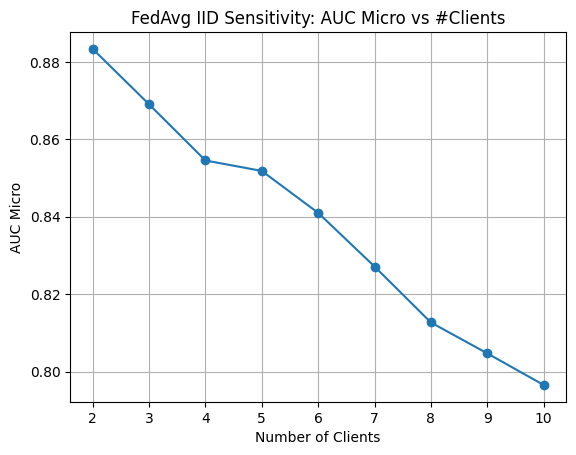

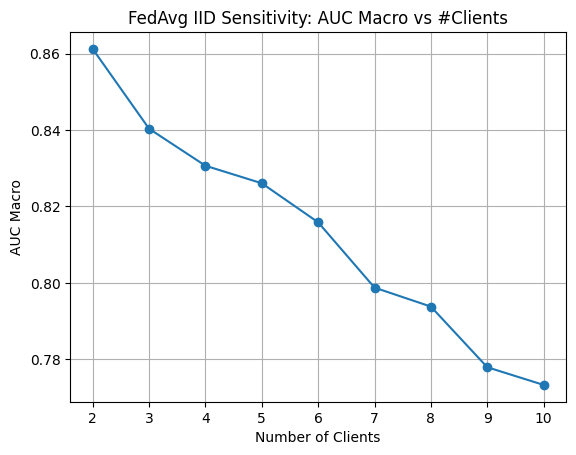

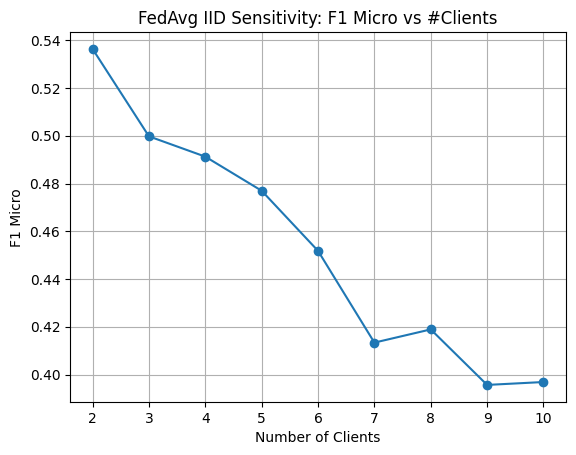

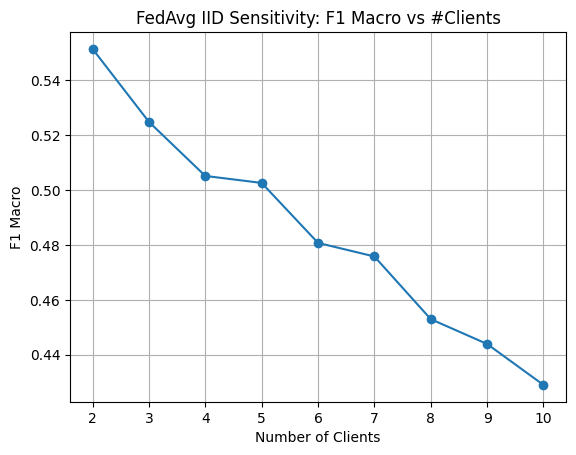

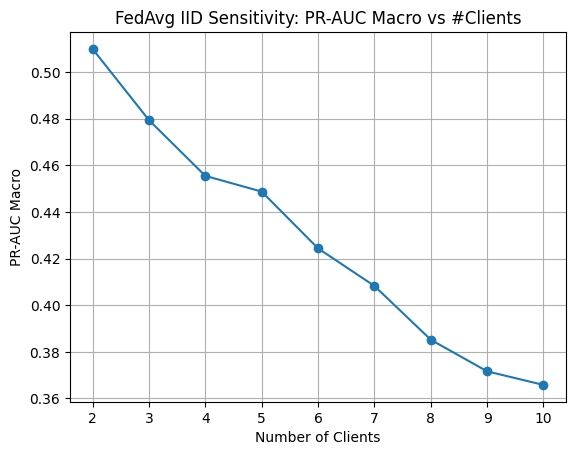

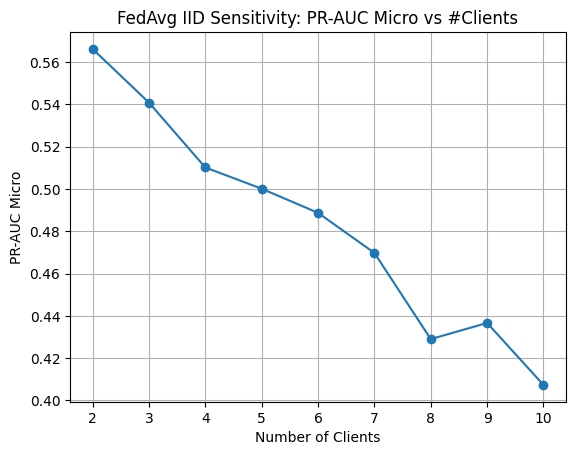

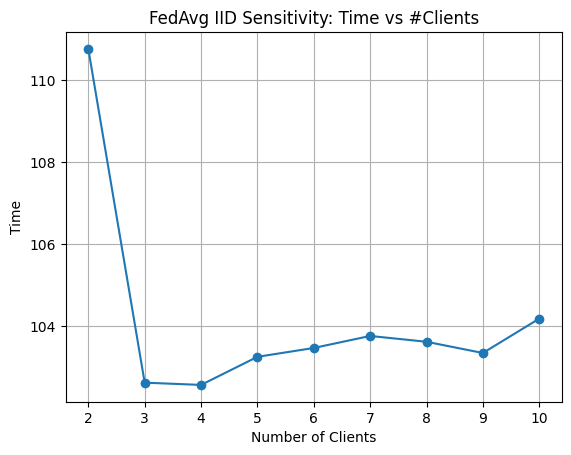

In [ ]:
#  # ---- Load sensitivity results if session restarted ----
# sens_path = "../History/client_sensitivity_fedavg_iid.csv"
# if "sens_results" not in globals():
#     if os.path.exists(sens_path):
#         sens_results = pd.read_csv(sens_path)
#         print(f"Loaded sens_results from {sens_path} ({len(sens_results)} rows).")
#     else:
#         raise FileNotFoundError(f"No saved sensitivity file found at: {sens_path}")

# # ---- Plot key metrics vs number of clients (Mullenbach-style) ----

# def plot_metric_vs_clients(df, metric_col: str, title: str):
#     xs = df["Clients"].values
#     ys = df[metric_col].values
#     plt.figure()
#     plt.plot(xs, ys, marker="o")
#     plt.xlabel("Number of Clients")
#     plt.ylabel(metric_col)
#     plt.title(title)
#     plt.grid(True)
#     plt.show()

# # AUC (micro/macro) + F1 (micro/macro)
# plot_metric_vs_clients(sens_results, "AUC Micro", "FedAvg IID Sensitivity: AUC Micro vs #Clients")
# plot_metric_vs_clients(sens_results, "AUC Macro", "FedAvg IID Sensitivity: AUC Macro vs #Clients")
# plot_metric_vs_clients(sens_results, "F1 Micro",  "FedAvg IID Sensitivity: F1 Micro vs #Clients")
# plot_metric_vs_clients(sens_results, "F1 Macro",  "FedAvg IID Sensitivity: F1 Macro vs #Clients")
# plot_metric_vs_clients(sens_results, "PR-AUC Macro",  "FedAvg IID Sensitivity: PR-AUC Macro vs #Clients")
# plot_metric_vs_clients(sens_results, "PR-AUC Micro",  "FedAvg IID Sensitivity: PR-AUC Micro vs #Clients")
# plot_metric_vs_clients(sens_results, "Time",  "FedAvg IID Sensitivity: Time vs #Clients")

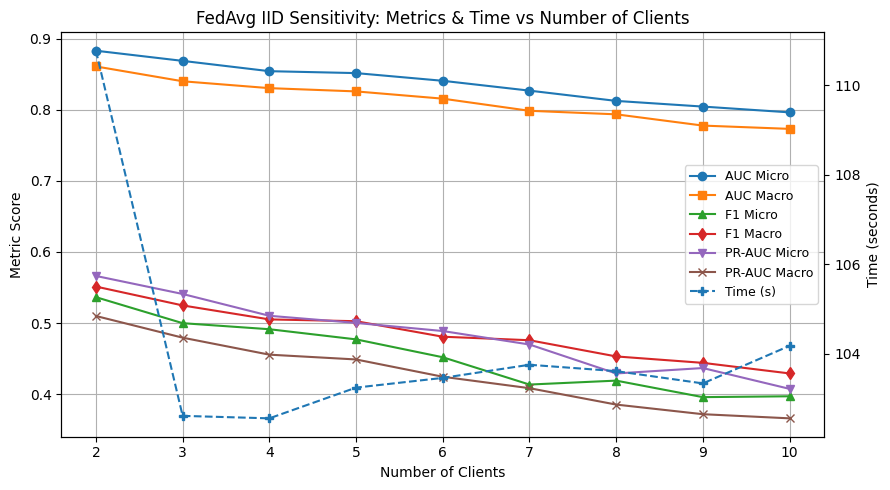

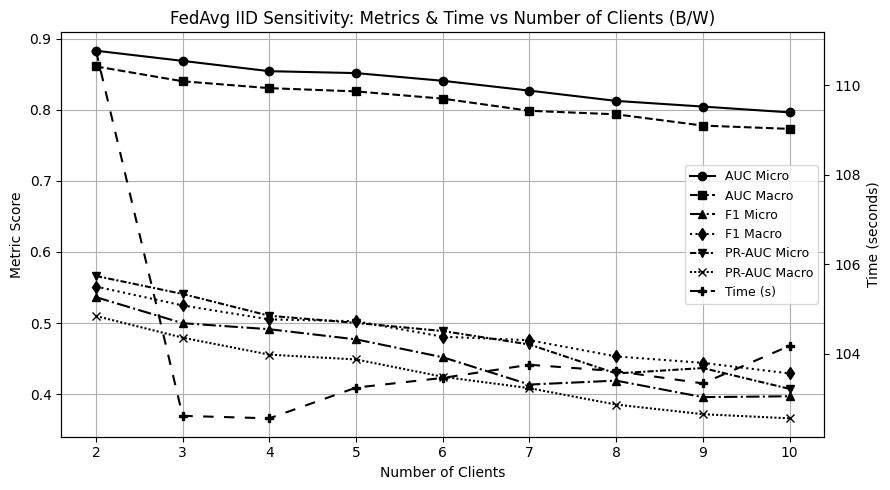

In [ ]:
# # ---- Load sensitivity results if session restarted ----
# sens_path = "../History/client_sensitivity_fedavg_iid.csv"
# if "sens_results" not in globals():
#     if os.path.exists(sens_path):
#         sens_results = pd.read_csv(sens_path)
#         print(f"Loaded sens_results from {sens_path} ({len(sens_results)} rows).")
#     else:
#         raise FileNotFoundError(f"No saved sensitivity file found at: {sens_path}")

# # Ensure sorted
# sens_results = sens_results.sort_values("Clients")

# # Extract values
# x = sens_results["Clients"].values
# auc_micro = sens_results["AUC Micro"].values
# auc_macro = sens_results["AUC Macro"].values
# f1_micro  = sens_results["F1 Micro"].values
# f1_macro  = sens_results["F1 Macro"].values
# pr_micro  = sens_results["PR-AUC Micro"].values
# pr_macro  = sens_results["PR-AUC Macro"].values
# time_vals = sens_results["Time"].values


# # =========================================================
# # COLOR VERSION
# # =========================================================
# fig, ax1 = plt.subplots(figsize=(9, 5))

# ax1.plot(x, auc_micro, marker="o", label="AUC Micro")
# ax1.plot(x, auc_macro, marker="s", label="AUC Macro")
# ax1.plot(x, f1_micro,  marker="^", label="F1 Micro")
# ax1.plot(x, f1_macro,  marker="d", label="F1 Macro")
# ax1.plot(x, pr_micro,  marker="v", label="PR-AUC Micro")
# ax1.plot(x, pr_macro,  marker="x", label="PR-AUC Macro")

# ax1.set_xlabel("Number of Clients")
# ax1.set_ylabel("Metric Score")
# ax1.set_title("FedAvg IID Sensitivity: Metrics & Time vs Number of Clients")
# ax1.grid(True)

# # Secondary axis for time
# ax2 = ax1.twinx()
# ax2.plot(x, time_vals, marker="P", linestyle="--", label="Time (s)")
# ax2.set_ylabel("Time (seconds)")

# # Combined legend
# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=9)

# plt.tight_layout()
# plt.show()


# # =========================================================
# # BLACK & WHITE VERSION
# # =========================================================
# fig, ax1 = plt.subplots(figsize=(9, 5))

# ax1.plot(x, auc_micro, linestyle="-",  marker="o", color="black", label="AUC Micro")
# ax1.plot(x, auc_macro, linestyle="--", marker="s", color="black", label="AUC Macro")
# ax1.plot(x, f1_micro,  linestyle="-.", marker="^", color="black", label="F1 Micro")
# ax1.plot(x, f1_macro,  linestyle=":",  marker="d", color="black", label="F1 Macro")
# ax1.plot(x, pr_micro,  linestyle=(0,(3,1,1,1)), marker="v", color="black", label="PR-AUC Micro")
# ax1.plot(x, pr_macro,  linestyle=(0,(1,1)),     marker="x", color="black", label="PR-AUC Macro")

# ax1.set_xlabel("Number of Clients")
# ax1.set_ylabel("Metric Score")
# ax1.set_title("FedAvg IID Sensitivity: Metrics & Time vs Number of Clients (B/W)")
# ax1.grid(True)

# # Secondary axis
# ax2 = ax1.twinx()
# ax2.plot(x, time_vals, linestyle=(0,(5,5)), marker="P", color="black", label="Time (s)")
# ax2.set_ylabel("Time (seconds)")

# # Combined legend
# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=9)

# plt.tight_layout()
# plt.show()

### Non-IID Split (Option B)

Multi-label non-IID split that simulates:
- size imbalance across hospitals (Dirichlet)
- per-hospital label-prevalence shifts (preferred labels + bias)

Parameters:
- size_alpha: smaller -> more size imbalance
- labels_per_client: how many "specialty" labels each client prefers
- bias_strength: probability of sampling examples that contain preferred labels

In [64]:
# Non-IID splitter for multi-label datasets

def split_dataset_noniid_multilabel(
    dataset,
    num_clients: int,
    seed: int = 42,
    size_alpha: float = 0.5,          # Dirichlet parameter for client sizes
    labels_per_client: int = 10,      # number of preferred labels per client
    bias_strength: float = 0.85       # prob of sampling from preferred-label examples
):
    """
    Splits `dataset` (TensorDataset or similar with Y in dataset.tensors[1])
    into `num_clients` Subset objects with non-IID label prevalence and size imbalance.
    """
    rng = np.random.default_rng(seed)

    # extract Y matrix
    if hasattr(dataset, "tensors"):
        Y = dataset.tensors[1].cpu()
    else:
        # fallback for generic dataset: collect Y
        Y = torch.stack([dataset[i][1] for i in range(len(dataset))]).cpu()

    n = len(dataset)
    n_labels = Y.shape[1]

    # --- sizes via Dirichlet ---
    props = rng.dirichlet(alpha=np.ones(num_clients) * size_alpha)
    sizes = (props * n).astype(int)
    diff = n - sizes.sum()
    for i in range(abs(diff)):
        sizes[i % num_clients] += 1 if diff > 0 else -1
    sizes = sizes.tolist()

    # --- label -> indices map ---
    label_to_indices = defaultdict(list)
    for idx in range(n):
        labs = torch.nonzero(Y[idx]).flatten().tolist()
        for lab in labs:
            label_to_indices[lab].append(idx)

    # --- preferred labels per client ---
    all_labels = np.arange(n_labels)
    preferred = []
    for _ in range(num_clients):
        preferred.append(rng.choice(all_labels, size=min(labels_per_client, n_labels), replace=False).tolist())

    # --- assignment ---
    unassigned = set(range(n))
    client_indices = [[] for _ in range(num_clients)]

    def pick_preferred(client_id):
        labs = preferred[client_id]
        candidates = []
        for lab in labs:
            candidates.extend(label_to_indices.get(lab, []))
        if not candidates:
            return None
        rng.shuffle(candidates)
        for idx in candidates:
            if idx in unassigned:
                return idx
        return None

    # fill clients
    for cid in range(num_clients):
        target = sizes[cid]
        while len(client_indices[cid]) < target and unassigned:
            use_pref = rng.random() < bias_strength
            idx = pick_preferred(cid) if use_pref else None

            if idx is None:
                # choose uniformly from remaining
                idx = rng.choice(list(unassigned))

            client_indices[cid].append(int(idx))
            unassigned.remove(int(idx))

    # distribute any leftovers
    if unassigned:
        leftovers = list(unassigned)
        rng.shuffle(leftovers)
        for i, idx in enumerate(leftovers):
            client_indices[i % num_clients].append(int(idx))

    # build subsets
    subsets = [Subset(dataset, inds) for inds in client_indices]
    return subsets

In [65]:
# Non-IID runner (same training loop as IID but using the non-IID splitter)

def run_fedavg_client_sensitivity_noniid(
    num_clients: int,
    local_epochs: int,
    config: dict,
    train_dataset,
    val_loader,
    test_loader,
    device,
    seed: int = 42,
    size_alpha: float = 0.5,
    labels_per_client: int = 10,
    bias_strength: float = 0.85
):
    start_time = time.time()

    # --- Split non-IID into K clients ---
    client_datasets = split_dataset_noniid_multilabel(
        train_dataset,
        num_clients=num_clients,
        seed=seed,
        size_alpha=size_alpha,
        labels_per_client=labels_per_client,
        bias_strength=bias_strength
    )

    client_sizes = [len(cd) for cd in client_datasets]
    client_loaders = [
        DataLoader(cd, batch_size=config["batch_size"], shuffle=True)
        for cd in client_datasets
    ]

    # --- Init global model ---
    global_model = GenerateModel(
        model_param_path,
        num_of_filters=config["n_filters"],
        kernel_size=config["window_size"]
    ).to(device)

    client_model = copy.deepcopy(global_model)

    # --- FL rounds ---
    for rnd in tqdm(range(config["rounds"]), colour="blue",
                    desc=f"FedAvg non-IID | K={num_clients} | E={local_epochs}"):
        client_params = []
        for loader in client_loaders:
            client_model.load_state_dict(global_model.state_dict())

            _, client_state, _ = client_update(
                model=client_model,
                train_loader=loader,
                epochs=local_epochs,
                lr=config["lr"],
                device=device,
                use_focal=config["use_focal"],
                gamma=config["gamma"],
                mu=config["mu"],
                global_params=None,
                c_global=None,
                c_local=None,
                algorithm="FedAvg"
            )
            client_params.append(client_state)

        # weighted aggregation (sample-size weighted FedAvg)
        new_params = FedAvg_weighted(client_params, client_sizes)
        global_model.load_state_dict(new_params)

    # --- Thresholds from val, evaluation on test ---
    _, per_label_thr = find_best_thresholds_per_label(global_model, val_loader, device)
    _, metrics = eval_model(global_model, device, test_loader, per_label_thr=per_label_thr)

    elapsed = time.time() - start_time
    return metrics, elapsed

In [ ]:
# # Sweep non-IID sensitivity (fast debug config)

# client_counts_b = [2, 3, 5, 8, 10]   # expand later if desired
# local_epochs  = 3
# algo_name     = "FedAvg-nonIID"

# fast_config = config.copy()
# fast_config["rounds"] = 10   # keep fast for debugging

# sens_results_b = pd.DataFrame(columns=[
#     "Algorithm", "Clients", "Local Epochs",
#     "AUC Macro", "AUC Micro",
#     "F1 Macro", "F1 Micro",
#     "PR-AUC Macro", "PR-AUC Micro",
#     "Time",
#     "size_alpha", "labels_per_client", "bias_strength"
# ])

# # choose a moderate heterogeneity setting by default
# # Mild: size_alpha=1.0, labels_per_client=15, bias_strength=0.7
# # Moderate: size_alpha=0.5, labels_per_client=10, bias_strength=0.85
# # Strong: size_alpha=0.3, labels_per_client=6, bias_strength=0.9
# size_alpha = 0.5
# labels_per_client = 10
# bias_strength = 0.85

# for k in client_counts_b:
#     print(f"\n=== Sensitivity (non-IID): {algo_name} | Clients={k} | Local Epochs={local_epochs} ===")

#     metrics, elapsed = run_fedavg_client_sensitivity_noniid(
#         num_clients=k,
#         local_epochs=local_epochs,
#         config=fast_config,
#         train_dataset=train_dataset,
#         val_loader=val_loader,
#         test_loader=test_loader,
#         device=device,
#         seed=42,
#         size_alpha=size_alpha,
#         labels_per_client=labels_per_client,
#         bias_strength=bias_strength
#     )

#     sens_results_b.loc[len(sens_results_b)] = [
#         algo_name, k, local_epochs,
#         metrics.get("auc_macro"),
#         metrics.get("auc_micro"),
#         metrics.get("f1_macro"),
#         metrics.get("f1_micro"),
#         metrics.get("pr_auc_macro"),
#         metrics.get("pr_auc_micro"),
#         elapsed,
#         size_alpha, labels_per_client, bias_strength
#     ]

#     sens_results_b.to_csv("../History/client_sensitivity_fedavg_noniid.csv", index=False)

# print("\nSensitivity sweep (non-IID) complete.")
# display(sens_results_b)


=== Sensitivity (non-IID): FedAvg-nonIID | Clients=2 | Local Epochs=3 ===


FedAvg non-IID | K=2 | E=3: 100%|██████████| 10/10 [02:12<00:00, 13.30s/it]


[Per-Label Thresholds] Macro F1=0.5230
[Eval] Avg loss=0.4631 | F1_micro=0.5322 | F1_macro=0.5410 | AUC_macro=0.8568 | AUC_micro=0.8798 | PR-AUC_macro=0.4987 | PR-AUC_micro=0.5550 | Best_F1=0.5322 @ thr=per-label | Avg labels/sample=9.46

=== Sensitivity (non-IID): FedAvg-nonIID | Clients=3 | Local Epochs=3 ===


FedAvg non-IID | K=3 | E=3: 100%|██████████| 10/10 [01:45<00:00, 10.54s/it]


[Per-Label Thresholds] Macro F1=0.2315
[Eval] Avg loss=0.6105 | F1_micro=0.2519 | F1_macro=0.2572 | AUC_macro=0.5788 | AUC_micro=0.6020 | PR-AUC_macro=0.1684 | PR-AUC_micro=0.1778 | Best_F1=0.2519 @ thr=per-label | Avg labels/sample=31.51

=== Sensitivity (non-IID): FedAvg-nonIID | Clients=5 | Local Epochs=3 ===


...

FedAvg non-IID | K=8 | E=3: 100%|██████████| 10/10 [01:44<00:00, 10.42s/it]


[Per-Label Thresholds] Macro F1=0.2508
[Eval] Avg loss=0.9600 | F1_micro=0.3082 | F1_macro=0.2596 | AUC_macro=0.6413 | AUC_micro=0.6198 | PR-AUC_macro=0.2339 | PR-AUC_micro=0.2248 | Best_F1=0.3082 @ thr=per-label | Avg labels/sample=13.86

=== Sensitivity (non-IID): FedAvg-nonIID | Clients=10 | Local Epochs=3 ===


FedAvg non-IID | K=10 | E=3: 100%|██████████| 10/10 [01:44<00:00, 10.45s/it]


[Per-Label Thresholds] Macro F1=0.3235
[Eval] Avg loss=0.8487 | F1_micro=0.3638 | F1_macro=0.3492 | AUC_macro=0.7156 | AUC_micro=0.6889 | PR-AUC_macro=0.3121 | PR-AUC_micro=0.3420 | Best_F1=0.3638 @ thr=per-label | Avg labels/sample=11.13

Sensitivity sweep (non-IID) complete.


,Algorithm,Clients,Local Epochs,AUC Macro,AUC Micro,F1 Macro,F1 Micro,PR-AUC Macro,PR-AUC Micro,Time,size_alpha,labels_per_client,bias_strength
0,FedAvg-nonIID,2,3,0.856806,0.879767,0.541011,0.532230,0.498663,0.554990,139.333796,0.5,10,0.85
1,FedAvg-nonIID,3,3,0.578799,0.602049,0.257206,0.251948,0.168392,0.177755,108.685529,0.5,10,0.85
2,FedAvg-nonIID,5,3,0.528596,0.583334,0.259500,0.226689,0.155737,0.169675,106.280016,0.5,10,0.85
3,FedAvg-nonIID,8,3,0.641264,0.619784,0.259574,0.308193,0.233865,0.224796,107.310562,0.5,10,0.85
4,FedAvg-nonIID,10,3,0.715557,0.688893,0.349181,0.363777,0.312143,0.342023,107.539312,0.5,10,0.85


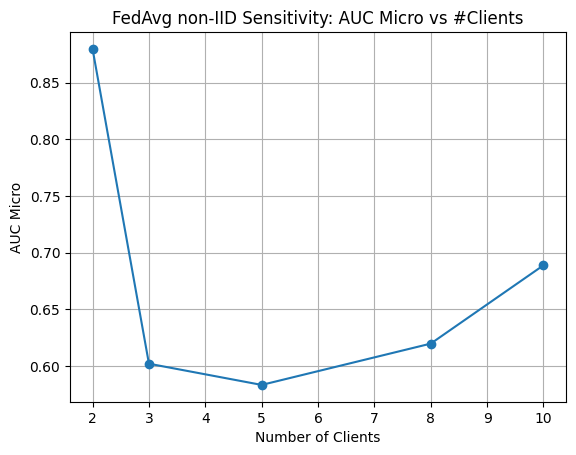

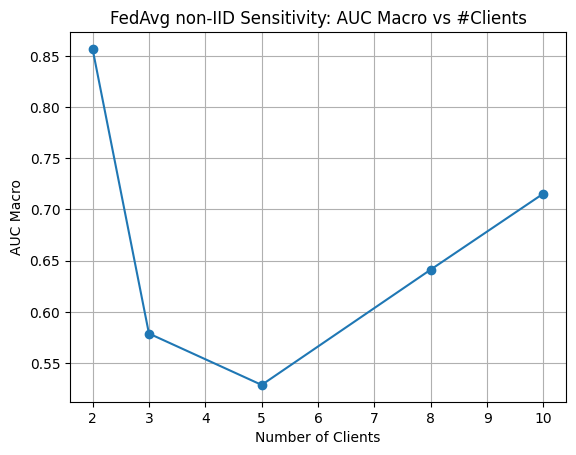

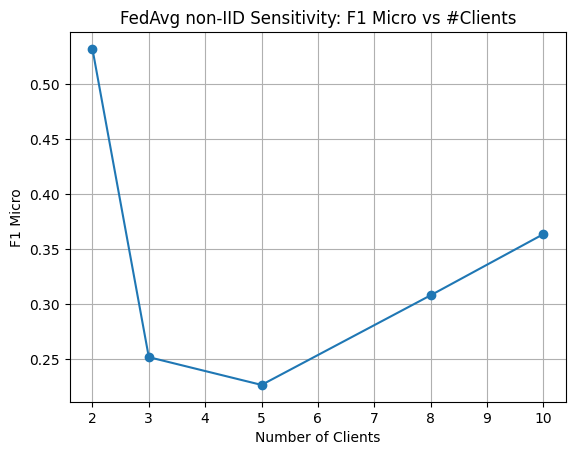

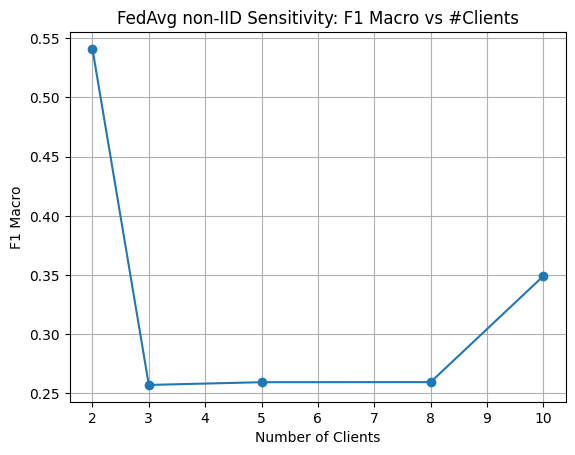

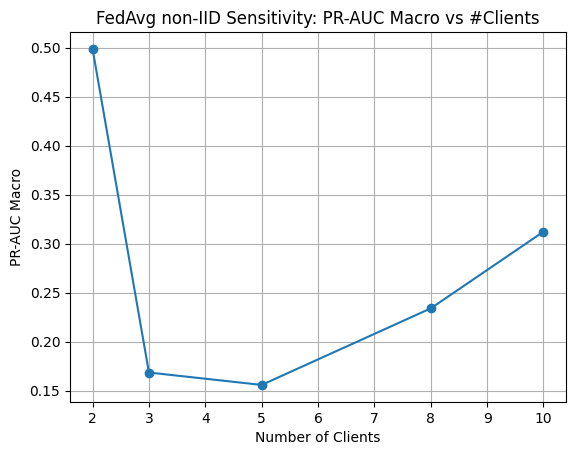

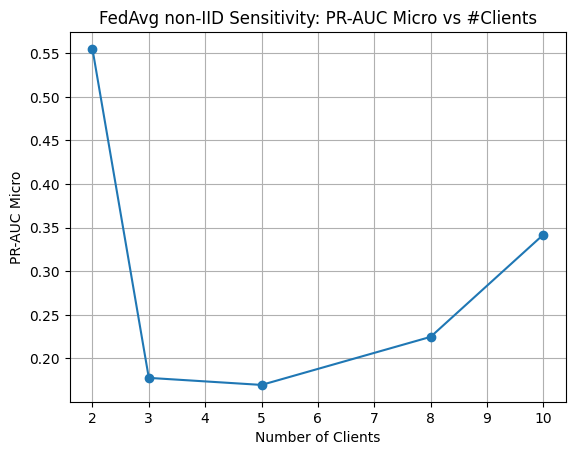

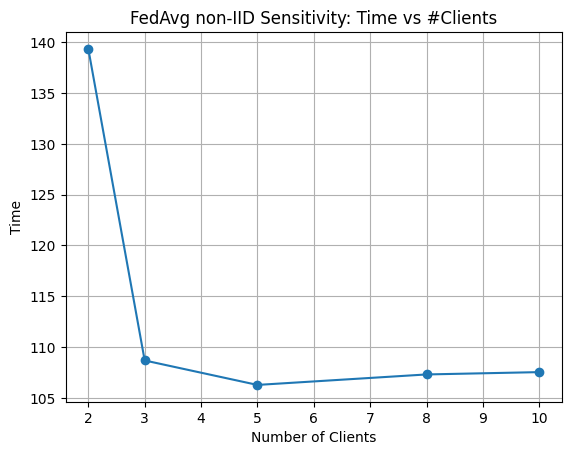

In [ ]:
# # ---- Load sensitivity results if session restarted (non-IID) ----
# sens_path_b = "../History/client_sensitivity_fedavg_noniid.csv"
# if "sens_results_b" not in globals():
#     if os.path.exists(sens_path_b):
#         sens_results_b = pd.read_csv(sens_path_b)
#         print(f"Loaded sens_results_b from {sens_path_b} ({len(sens_results_b)} rows).")
#     else:
#         raise FileNotFoundError(f"No saved sensitivity file found at: {sens_path_b}")

# # Simple Mullenbach-style plots (single metric per figure)
# def plot_metric_vs_clients_b(df, metric_col: str, title: str):
#     xs = df["Clients"].values
#     ys = df[metric_col].values
#     plt.figure()
#     plt.plot(xs, ys, marker="o")
#     plt.xlabel("Number of Clients")
#     plt.ylabel(metric_col)
#     plt.title(title)
#     plt.grid(True)
#     plt.show()

# plot_metric_vs_clients_b(sens_results_b, "AUC Micro", "FedAvg non-IID Sensitivity: AUC Micro vs #Clients")
# plot_metric_vs_clients_b(sens_results_b, "AUC Macro", "FedAvg non-IID Sensitivity: AUC Macro vs #Clients")
# plot_metric_vs_clients_b(sens_results_b, "F1 Micro",  "FedAvg non-IID Sensitivity: F1 Micro vs #Clients")
# plot_metric_vs_clients_b(sens_results_b, "F1 Macro",  "FedAvg non-IID Sensitivity: F1 Macro vs #Clients")
# plot_metric_vs_clients_b(sens_results_b, "PR-AUC Macro",  "FedAvg non-IID Sensitivity: PR-AUC Macro vs #Clients")
# plot_metric_vs_clients_b(sens_results_b, "PR-AUC Micro",  "FedAvg non-IID Sensitivity: PR-AUC Micro vs #Clients")
# plot_metric_vs_clients_b(sens_results_b, "Time",  "FedAvg non-IID Sensitivity: Time vs #Clients")

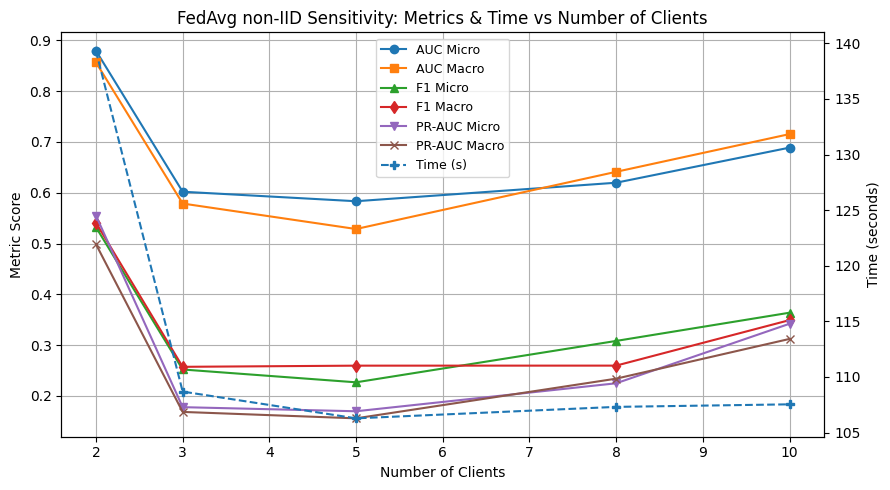

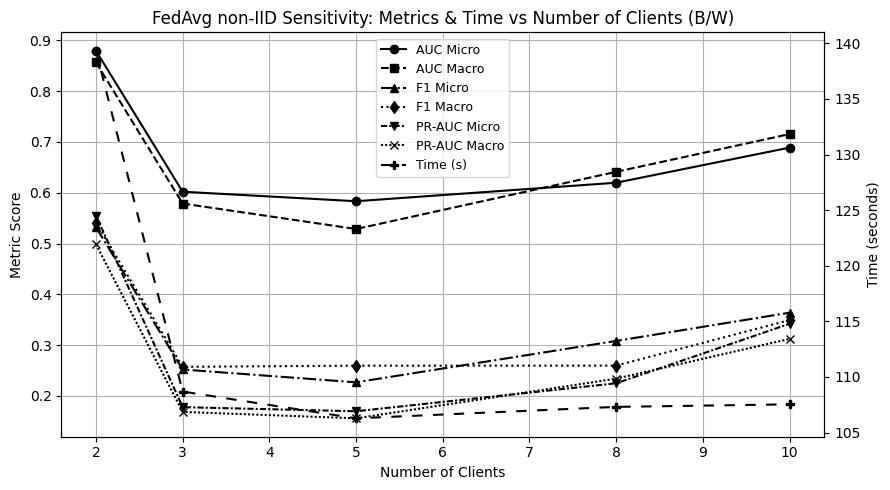

In [ ]:
# # ---- Combined color + black & white plots for non-IID (metrics + time on secondary axis) ----

# # Ensure sorted
# sens_results_b = sens_results_b.sort_values("Clients")

# x = sens_results_b["Clients"].values
# auc_micro = sens_results_b["AUC Micro"].values
# auc_macro = sens_results_b["AUC Macro"].values
# f1_micro  = sens_results_b["F1 Micro"].values
# f1_macro  = sens_results_b["F1 Macro"].values
# pr_micro  = sens_results_b["PR-AUC Micro"].values
# pr_macro  = sens_results_b["PR-AUC Macro"].values
# time_vals = sens_results_b["Time"].values

# # COLOR
# fig, ax1 = plt.subplots(figsize=(9, 5))

# ax1.plot(x, auc_micro, marker="o", label="AUC Micro")
# ax1.plot(x, auc_macro, marker="s", label="AUC Macro")
# ax1.plot(x, f1_micro,  marker="^", label="F1 Micro")
# ax1.plot(x, f1_macro,  marker="d", label="F1 Macro")
# ax1.plot(x, pr_micro,  marker="v", label="PR-AUC Micro")
# ax1.plot(x, pr_macro,  marker="x", label="PR-AUC Macro")

# ax1.set_xlabel("Number of Clients")
# ax1.set_ylabel("Metric Score")
# ax1.set_title("FedAvg non-IID Sensitivity: Metrics & Time vs Number of Clients")
# ax1.grid(True)

# ax2 = ax1.twinx()
# ax2.plot(x, time_vals, marker="P", linestyle="--", label="Time (s)")
# ax2.set_ylabel("Time (seconds)")

# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=9)

# plt.tight_layout()
# plt.show()

# # BLACK & WHITE
# fig, ax1 = plt.subplots(figsize=(9, 5))

# ax1.plot(x, auc_micro, linestyle="-",  marker="o", color="black", label="AUC Micro")
# ax1.plot(x, auc_macro, linestyle="--", marker="s", color="black", label="AUC Macro")
# ax1.plot(x, f1_micro,  linestyle="-.", marker="^", color="black", label="F1 Micro")
# ax1.plot(x, f1_macro,  linestyle=":",  marker="d", color="black", label="F1 Macro")
# ax1.plot(x, pr_micro,  linestyle=(0,(3,1,1,1)), marker="v", color="black", label="PR-AUC Micro")
# ax1.plot(x, pr_macro,  linestyle=(0,(1,1)),     marker="x", color="black", label="PR-AUC Macro")

# ax1.set_xlabel("Number of Clients")
# ax1.set_ylabel("Metric Score")
# ax1.set_title("FedAvg non-IID Sensitivity: Metrics & Time vs Number of Clients (B/W)")
# ax1.grid(True)

# ax2 = ax1.twinx()
# ax2.plot(x, time_vals, linestyle=(0,(5,5)), marker="P", color="black", label="Time (s)")
# ax2.set_ylabel("Time (seconds)")

# lines1, labels1 = ax1.get_legend_handles_labels()
# lines2, labels2 = ax2.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, loc="best", fontsize=9)

# plt.tight_layout()
# plt.show()

### Targeted Sensitivity Analysis

In [66]:
def run_fl_sensitivity_once(
    split_mode: str,            # "iid" or "noniid"
    num_clients: int,
    local_epochs: int,
    config: dict,
    train_dataset,
    val_loader,
    test_loader,
    device,
    seed: int = 42,
    algo: str = "FedAvg",        # "FedAvg" or "FedProx"
    mu: float = 0.01,            # only used for FedProx
    # non-IID params
    size_alpha: float = 0.5,
    labels_per_client: int = 10,
    bias_strength: float = 0.85
):
    start_time = time.time()

    # --- split ---
    if split_mode == "iid":
        client_datasets = split_dataset_iid(train_dataset, num_clients=num_clients, seed=seed)
    elif split_mode == "noniid":
        client_datasets = split_dataset_noniid_multilabel(
            train_dataset,
            num_clients=num_clients,
            seed=seed,
            size_alpha=size_alpha,
            labels_per_client=labels_per_client,
            bias_strength=bias_strength
        )
    else:
        raise ValueError("split_mode must be 'iid' or 'noniid'")

    client_sizes = [len(cd) for cd in client_datasets]
    client_loaders = [DataLoader(cd, batch_size=config["batch_size"], shuffle=True) for cd in client_datasets]

    # --- init global model ---
    global_model = GenerateModel(
        model_param_path,
        num_of_filters=config["n_filters"],
        kernel_size=config["window_size"]
    ).to(device)

    client_model = copy.deepcopy(global_model)

    # --- FL rounds ---
    for rnd in tqdm(range(config["rounds"]), colour="blue",
                    desc=f"{algo} {split_mode} | K={num_clients} | E={local_epochs}"):
        client_params = []
        for loader in client_loaders:
            client_model.load_state_dict(global_model.state_dict())

            _, client_state, _ = client_update(
                model=client_model,
                train_loader=loader,
                epochs=local_epochs,
                lr=config["lr"],
                device=device,
                use_focal=config["use_focal"],
                gamma=config["gamma"],
                mu=mu,
                global_params=(global_model.state_dict() if algo == "FedProx" else None),
                c_global=None,
                c_local=None,
                algorithm=algo,
            )
            client_params.append(client_state)

        # server aggregation: sample-size weighted FedAvg (safe for IID + nonIID)
        new_params = FedAvg_weighted(client_params, client_sizes)
        global_model.load_state_dict(new_params)

    # --- eval ---
    _, per_label_thr = find_best_thresholds_per_label(global_model, val_loader, device)
    _, metrics = eval_model(global_model, device, test_loader, per_label_thr=per_label_thr)

    elapsed = time.time() - start_time
    return metrics, elapsed

In [70]:
# =========================
# Sensitivity Sweep (FULL)
# =========================

client_counts = [2, 3, 5, 8, 10]      # 2–20 as requested

# keep fast first; later bump rounds to your real value
sweep_config = config.copy()
sweep_config["rounds"] = 10  # debug; set higher later

# choose non-IID severity (keep fixed across all methods)
noniid_params = dict(size_alpha=0.5, labels_per_client=10, bias_strength=0.85)

# methods to compare
METHODS = [
    #dict(method="FedAvg",  algo="FedAvg",  mu=None,  local_epochs=3)
    dict(method="FedAvg_E1", algo="FedAvg", mu=None, local_epochs=1),

    #dict(method="FedProx_mu0.01_E3", algo="FedProx", mu=0.01, local_epochs=3)
    #dict(method="FedProx_mu0.1_E3",  algo="FedProx", mu=0.10, local_epochs=3)

    dict(method="FedProx_mu0.01_E1", algo="FedProx", mu=0.01, local_epochs=1),
    dict(method="FedProx_mu0.1_E1",  algo="FedProx", mu=0.10, local_epochs=1),

]

out_path = "../History/sensitivity_all_methods.csv"

all_rows = []
for split_mode in ["iid", "noniid"]:
    for m in METHODS:
        for k in client_counts:
            print(f"\n=== {split_mode.upper()} | {m['method']} | K={k} ===")

            metrics, elapsed = run_fl_sensitivity_once(
                split_mode=split_mode,
                num_clients=k,
                local_epochs=m["local_epochs"],
                config=sweep_config,
                train_dataset=train_dataset,
                val_loader=val_loader,
                test_loader=test_loader,
                device=device,
                seed=42,
                algo=m["algo"],
                mu=(m["mu"] if m["mu"] is not None else 0.0),
                **(noniid_params if split_mode == "noniid" else {})
            )

            row = dict(
                split=split_mode,
                method=m["method"],
                algo=m["algo"],
                mu=m["mu"],
                local_epochs=m["local_epochs"],
                clients=k,
                auc_macro=metrics.get("auc_macro"),
                auc_micro=metrics.get("auc_micro"),
                f1_macro=metrics.get("f1_macro"),
                f1_micro=metrics.get("f1_micro"),
                pr_auc_macro=metrics.get("pr_auc_macro"),
                pr_auc_micro=metrics.get("pr_auc_micro"),
                time_sec=elapsed,
            )
            if split_mode == "noniid":
                row.update(noniid_params)

            all_rows.append(row)

            pd.DataFrame(all_rows).to_csv(out_path, index=False)

print(f"\nDone. Saved to {out_path}")
sens_all = pd.DataFrame(all_rows)
display(sens_all)


=== IID | FedAvg_E1 | K=2 ===


FedAvg iid | K=2 | E=1: 100%|██████████| 10/10 [00:34<00:00,  3.48s/it]


[Per-Label Thresholds] Macro F1=0.4606
[Eval] Avg loss=0.5057 | F1_micro=0.4545 | F1_macro=0.4888 | AUC_macro=0.8156 | AUC_micro=0.8432 | PR-AUC_macro=0.4270 | PR-AUC_micro=0.4917 | Best_F1=0.4545 @ thr=per-label | Avg labels/sample=11.71

=== IID | FedAvg_E1 | K=3 ===


FedAvg iid | K=3 | E=1: 100%|██████████| 10/10 [00:35<00:00,  3.55s/it]


[Per-Label Thresholds] Macro F1=0.4310
[Eval] Avg loss=0.5332 | F1_micro=0.4213 | F1_macro=0.4522 | AUC_macro=0.7920 | AUC_micro=0.8125 | PR-AUC_macro=0.3907 | PR-AUC_micro=0.4432 | Best_F1=0.4213 @ thr=per-label | Avg labels/sample=12.57

=== IID | FedAvg_E1 | K=5 ===


...

FedProx noniid | K=8 | E=1: 100%|██████████| 10/10 [00:48<00:00,  4.80s/it]


[Per-Label Thresholds] Macro F1=0.2424
[Eval] Avg loss=0.6091 | F1_micro=0.2533 | F1_macro=0.2603 | AUC_macro=0.5924 | AUC_micro=0.5769 | PR-AUC_macro=0.1805 | PR-AUC_micro=0.1842 | Best_F1=0.2533 @ thr=per-label | Avg labels/sample=30.41

=== NONIID | FedProx_mu0.1_E1 | K=10 ===


FedProx noniid | K=10 | E=1: 100%|██████████| 10/10 [00:48<00:00,  4.80s/it]


[Per-Label Thresholds] Macro F1=0.2452
[Eval] Avg loss=0.6328 | F1_micro=0.2546 | F1_macro=0.2776 | AUC_macro=0.6028 | AUC_micro=0.5835 | PR-AUC_macro=0.1902 | PR-AUC_micro=0.1683 | Best_F1=0.2546 @ thr=per-label | Avg labels/sample=30.62

Done. Saved to ../History/sensitivity_all_methods.csv


,split,method,algo,mu,local_epochs,clients,auc_macro,auc_micro,f1_macro,f1_micro,pr_auc_macro,pr_auc_micro,time_sec,size_alpha,labels_per_client,bias_strength
0,iid,FedAvg_E1,FedAvg,NaN,1,2,0.815557,0.843185,0.488772,0.454542,0.426986,0.491718,36.568131,NaN,NaN,NaN
1,iid,FedAvg_E1,FedAvg,NaN,1,3,0.792010,0.812472,0.452213,0.421281,0.390742,0.443171,37.342356,NaN,NaN,NaN
2,iid,FedAvg_E1,FedAvg,NaN,1,5,0.746349,0.767531,0.393330,0.355199,0.328028,0.364115,39.775120,NaN,NaN,NaN
3,iid,FedAvg_E1,FedAvg,NaN,1,8,0.735231,0.743957,0.378021,0.344734,0.302352,0.325977,41.588521,NaN,NaN,NaN
4,iid,FedAvg_E1,FedAvg,NaN,1,10,0.720231,0.732559,0.363978,0.333373,0.291142,0.310740,43.046266,NaN,NaN,NaN
5,iid,FedProx_mu0.01_E1,FedProx,0.01,1,2,0.783116,0.804673,0.448714,0.410767,0.385451,0.429537,46.816653,NaN,NaN,NaN
6,iid,FedProx_mu0.01_E1,FedProx,0.01,1,3,0.768904,0.788524,0.420484,0.390915,0.354017,0.380009,47.682855,NaN,NaN,NaN
7,iid,FedProx_mu0.01_E1,FedProx,0.01,1,5,0.744050,0.758798,0.383576,0.365217,0.317078,0.340648,48.699487,NaN,NaN,NaN
8,iid,FedProx_mu0.01_E1,FedProx,0.01,1,8,0.720742,0.735844,0.357668,0.338283,0.286140,0.316150,49.701269,NaN,NaN,NaN
9,iid,FedProx_mu0.01_E1,FedProx,0.01,1,10,0.713650,0.724872,0.350321,0.337985,0.280141,0.298566,49.291438,NaN,NaN,NaN


In [71]:
# Load + table (primary metrics)

out_path = "../History/sensitivity_all_methods.csv"
sens_all = pd.read_csv(out_path)
print("Loaded:", out_path, "rows=", len(sens_all))

# Comparison table: primary metrics (Macro F1, PR-AUC Macro)
table = sens_all[["split","method","clients","f1_macro","pr_auc_macro","time_sec"]].copy()
display(table.head())

Loaded: ../History/sensitivity_all_methods.csv rows= 30


,split,method,clients,f1_macro,pr_auc_macro,time_sec
0,iid,FedAvg_E1,2,0.488772,0.426986,36.568131
1,iid,FedAvg_E1,3,0.452213,0.390742,37.342356
2,iid,FedAvg_E1,5,0.393330,0.328028,39.775120
3,iid,FedAvg_E1,8,0.378021,0.302352,41.588521
4,iid,FedAvg_E1,10,0.363978,0.291142,43.046266


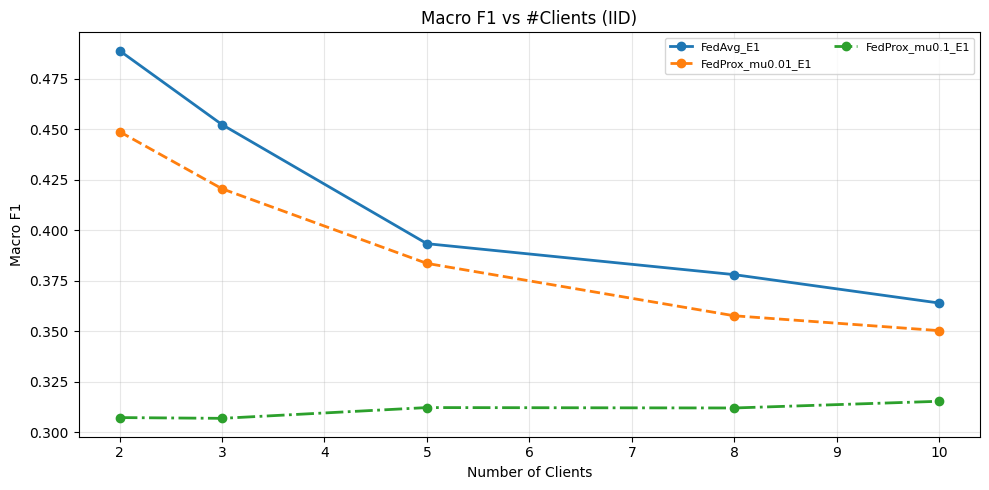

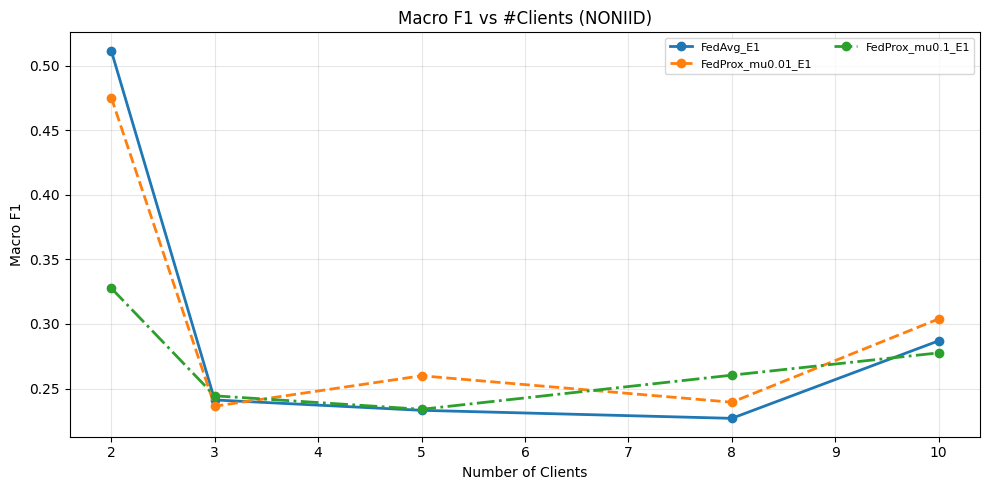

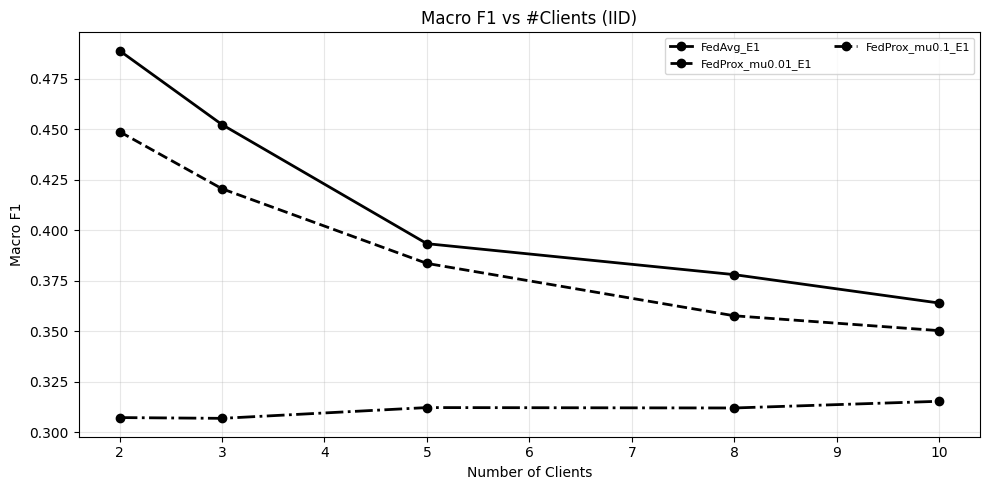

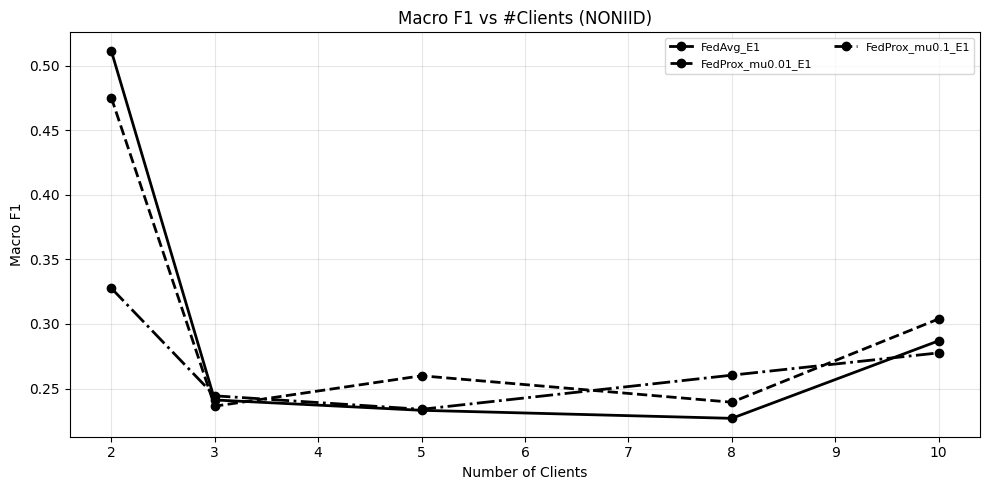

In [75]:
# Plotting

# Pre-define visually distinct markers/linestyles (works for both color and B/W)
MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">"]
LINESTYLES = ["-", "--", "-.", ":", (0,(3,1,1,1)), (0,(5,5)), (0,(1,1))]

def plot_macro_f1_all_methods(df, split_mode: str, bw: bool = False):
    d = df[df["split"] == split_mode].copy()

    # consistent order in legend (so runs are stable)
    methods = sorted(d["method"].unique())

    plt.figure(figsize=(10, 5))

    # cycle marker/style pairs so each method is distinguishable
    style_cycle = itertools.cycle([
        (m, ls) for m in MARKERS for ls in LINESTYLES
    ])

    for method in methods:
        g = d[d["method"] == method].sort_values("clients")
        marker, ls = next(style_cycle)

        if bw:
            plt.plot(
                g["clients"], g["f1_macro"],
                color="black",
                linestyle=ls,
                marker=marker,
                markersize=6,
                linewidth=2,
                label=method
            )
        else:
            plt.plot(
                g["clients"], g["f1_macro"],
                linestyle=ls,
                marker=marker,
                markersize=6,
                linewidth=2,
                label=method
            )

    plt.xlabel("Number of Clients")
    plt.ylabel("Macro F1")
    plt.title(f"Macro F1 vs #Clients ({split_mode.upper()})")
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8, ncols=2, frameon=True)
    plt.tight_layout()
    plt.show()

# Color
plot_macro_f1_all_methods(sens_all, "iid", bw=False)
plot_macro_f1_all_methods(sens_all, "noniid", bw=False)

# Black & White
plot_macro_f1_all_methods(sens_all, "iid", bw=True)
plot_macro_f1_all_methods(sens_all, "noniid", bw=True)